# SABER CTI Realm Evaluation Analysis

## Purpose

**Self-contained** analysis notebook for the **CTI Realm** cyber threat intelligence domain. Includes all domain-agnostic analysis (scores, cost, tokens, sub-tasks, agent trajectory) plus CTI Realm-specific experiments that leverage the domain's 5-checkpoint scoring system, KQL query analysis, and CTI tool usage patterns.

**What is CTI Realm?** A benchmark where AI agents create detection rules from threat intelligence — given a detection objective, agents must research CTI reports, map MITRE ATT&CK techniques, explore data schemas, write KQL queries, and generate Sigma rules. 25 tasks across 3 platforms (Linux, AKS, Cloud) with 5 scored checkpoints totaling 10.0 points.

### Analyses included

| # | Analysis | Domain-Agnostic? |
|---|----------|------------------|
| 1 | Overall Reward Distribution | ✓ Generic |
| 2 | **Per-Platform Breakdown** | **CTI Realm-specific** (Linux / AKS / Cloud grouping) |
| 3 | Cost Analysis & Pareto | ✓ Generic |
| 4 | Token Usage Breakdown | ✓ Generic |
| 5 | Cost Efficiency (Reward/$) | ✓ Generic |
| 6 | Sub-Task Decomposition | ✓ Generic |
| 7 | Checkpoint Distributions | ✓ Generic |
| 8 | **Per-Checkpoint Score Heatmap** | **CTI Realm-specific** (C0–C4 × Model heatmap) |
| 9 | Agent Trajectory Analysis (data loading) | ✓ Generic |
| 9a | Score vs. Tool-Call Limit | ✓ Generic |
| 9b | Effort Distribution (tool calls & steps) | ✓ Generic |
| 10 | Tool Usage Analysis | ✓ Generic |
| 11 | Time Efficiency & Reward Per Tool Call | ✓ Generic |
| 12 | Score Outcome Segmentation by Effort | ✓ Generic |
| 13 | Cross-Model Difficulty Agreement | ✓ Generic |
| 14 | **CTI Tool Usage & Report Analysis** | **CTI Realm-specific** (tool call patterns, CTI report access) |
| 15 | **KQL Query Quality Analysis** | **CTI Realm-specific** (query success/error rates, F1 correlation) |
| 16 | **Checkpoint Correlation Analysis** | **CTI Realm-specific** (C0↔C4 grounding vs. detection quality) |

> **Domain-specific experiments (2, 8, 14–16)** are unique to CTI Realm. They analyze multi-checkpoint scoring, KQL query quality, and how CTI grounding correlates with detection effectiveness.

For domain-agnostic analysis applicable to any domain, see [`eval_analysis.ipynb`](eval_analysis.ipynb).

### Sample models

| Model | API ID | Provider |
|-------|--------|----------|
| Claude Haiku 4.5 | `anthropic/claude-haiku-4-5` | Anthropic |
| Claude Sonnet 4.6 | `anthropic/claude-sonnet-4-6` | Anthropic |
| Claude Opus 4.6 | `anthropic/claude-opus-4-6` | Anthropic |
| GPT-5.4 | `openai/azure/gpt-5.4` | Azure OpenAI |
| GPT-5.4-mini | `openai/azure/gpt-5.4-mini` | Azure OpenAI |

## Prerequisites & Running CTI Realm Evaluations

```bash
# Install
uv sync --all-extras
cp .env.template .env  # Configure API keys

# Build Docker images (required first time — ~6.5 GB)
uv run saber build cti_realm

# Quick test (1 sample)
uv run inspect eval domains/cti_realm --model anthropic/claude-haiku-4-5 --display plain --limit 1

# Full evaluation (25 samples)
uv run inspect eval domains/cti_realm --model anthropic/claude-sonnet-4-6 --display plain

# With parallel execution and permanent services
uv run inspect eval domains/cti_realm --model anthropic/claude-sonnet-4-6 \
  --display plain --max-samples 4 --max-connections 20 -T keep_permanent=true

# Teardown permanent services when done
uv run saber teardown -y
```

### Viewing results

- **VS Code:** Install the **Inspect AI** extension → click any `.eval` file
- **Browser:** `uv run inspect view` → http://localhost:7575

Copy `.eval` files to `latest_experiments/cti_realm/` with descriptive names. See [README.md](../README.md) for full documentation.

<a id="configuration"></a>
## Configuration

Edit the cell below to add your own models. See [`eval_analysis.ipynb`](eval_analysis.ipynb) for detailed configuration instructions.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — CTI Realm domain
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from inspect_ai.log import read_eval_log

NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_baseline_logs, ensure_eval_files, load_trajectory_data
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

DOMAIN_NAME = 'CTI Realm'
DOMAIN_SLUG = 'cti_realm'
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = str(REPO_ROOT / 'eval_samples' / DOMAIN_SLUG)
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts' / 'cti_realm'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_LOGS = {
    'Claude Haiku 4.5':  'haiku_4.5_cti_realm_25.eval',
    'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25.eval',
    'Claude Opus 4.6':   'opus_4.6_cti_realm_25.eval',
    'GPT-5.4':           'gpt_5.4_cti_realm_25.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_cti_realm_25.eval',
}

NO_THINKING_LOGS = {
    'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25_no_thinking.eval',
    'Claude Opus 4.6':   'opus_4.6_cti_realm_25_no_thinking.eval',
    'GPT-5.4':           'gpt_5.4_cti_realm_25_no_reasoning.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_cti_realm_25_no_reasoning.eval',
}

COLORS = {
    'Claude Haiku 4.5':  '#17BECF',  # cyan
    'Claude Sonnet 4.6': '#F39C12',  # orange
    'Claude Opus 4.6':   '#E74C3C',  # red
    'GPT-5.4':           '#2CA02C',  # green
    'GPT-5.4-mini':      '#7B4FBF',  # purple
}

N_SAMPLES = 25  # cti_realm_25 dataset
MODEL_ORDER = list(EVAL_LOGS.keys())

# CTI Realm groups by platform (derived from task_id prefix: linux_*, aks_*, cloud_*)
GROUP_FN = lambda sid: sid.split('_')[0]
GROUP_LABEL = 'Platform'

PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini':             {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

# CTI Realm checkpoint names (for domain-specific analysis)
CHECKPOINT_NAMES = {
    'c0_cti_analysis': 'C0: CTI Alignment',
    'c1_mitre_techniques': 'C1: MITRE Techniques',
    'c2_data_exploration': 'C2: Data Exploration',
    'c3_query_iteration': 'C3: Query Iteration',
    'c4_detection_quality': 'C4: Detection Quality',
}
CHECKPOINT_MAX_SCORES = {
    'c0_cti_analysis': 1.25,
    'c1_mitre_techniques': 0.75,
    'c2_data_exploration': 1.0,
    'c3_query_iteration': 0.5,
    'c4_detection_quality': 6.5,
}

ensure_eval_files(
    EVAL_LOGS, LOG_DIR, DOMAIN_SLUG,
    baseline_logs=NO_THINKING_LOGS,
    fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG)],
)

# Auto-detect tool-call limit from eval log headers
_first_log_path = os.path.join(LOG_DIR, next(iter(EVAL_LOGS.values())))
_log_header = read_eval_log(_first_log_path, header_only=True)
TOOL_CALL_LIMIT = _log_header.eval.config.tool_call_limit or 70
TIME_LIMIT = _log_header.eval.config.time_limit

print(f'✓ Domain: {DOMAIN_NAME}')
print(f'  Models: {len(EVAL_LOGS)} ({", ".join(MODEL_ORDER)})')
print(f'  Samples: {N_SAMPLES}')
print(f'  Tool-call limit: {TOOL_CALL_LIMIT} (from eval header)')
print(f'  Time limit: {TIME_LIMIT}s' if TIME_LIMIT else '  Time limit: none')
print(f'  Log dir: {LOG_DIR}')

✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/cti_realm
✓ Domain: CTI Realm
  Models: 5 (Claude Haiku 4.5, Claude Sonnet 4.6, Claude Opus 4.6, GPT-5.4, GPT-5.4-mini)
  Samples: 25
  Tool-call limit: 70 (from eval header)
  Time limit: 3600s
  Log dir: /home/amudgerikar/repos/oss_saber/eval_samples/cti_realm


## Data Loading

### What this does

Parses all `.eval` ZIP archives and extracts structured DataFrames:

- **`samples_df`** — per-sample `saber_overall` scores (0–1, normalized from 0–10 raw) with platform group labels
- **`subtasks_df`** — per-sample per-checkpoint scores (C0–C4) with score type classification
- **`overall_df`** — mean ± stderr per model
- **`baseline_samples_df`** / **`no_thinking_overall`** — same metrics for no-reasoning baseline runs

### Platform labels

Derived from sample IDs using `GROUP_FN = lambda sid: sid.split('_')[0]`:
- `linux_*` → Linux (15 tasks)
- `aks_*` → AKS (6 tasks)
- `cloud_*` → Cloud (4 tasks)

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
    EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN
)
baseline_samples_df, baseline_subtasks_df, no_thinking_overall = load_baseline_logs(
    NO_THINKING_LOGS, LOG_DIR, group_fn=GROUP_FN
)

print(f'\n✓ Loaded {len(samples_df)} sample scores across {samples_df["model"].nunique()} models')
print(f'✓ Loaded {len(subtasks_df)} sub-task scores')
print(f'✓ Platforms: {sorted(samples_df["group"].unique())}')
print()
print('═══ Overall SABER Scores (with extended reasoning) ═══')
for m in MODEL_ORDER:
    if m in model_overall:
        r = overall_df.loc[m]
        print(f'  {m:25s}  mean={r["mean"]:.4f}  stderr={r["stderr"]:.4f}')
print()
print('═══ Baselines (without extended reasoning) ═══')
for m, r in no_thinking_overall.items():
    if m in model_overall:
        delta = model_overall[m]['mean'] - r['mean']
        print(f'  {m:25s}  baseline={r["mean"]:.4f}  reasoning={model_overall[m]["mean"]:.4f}  Δ={delta:+.4f}')


✓ Loaded 125 sample scores across 5 models
✓ Loaded 750 sub-task scores
✓ Platforms: ['aks', 'cloud', 'linux']

═══ Overall SABER Scores (with extended reasoning) ═══
  Claude Haiku 4.5           mean=0.4939  stderr=0.0426
  Claude Sonnet 4.6          mean=0.5467  stderr=0.0473
  Claude Opus 4.6            mean=0.6263  stderr=0.0473
  GPT-5.4                    mean=0.6199  stderr=0.0500
  GPT-5.4-mini               mean=0.6167  stderr=0.0544

═══ Baselines (without extended reasoning) ═══
  Claude Sonnet 4.6          baseline=0.5678  reasoning=0.5467  Δ=-0.0211
  Claude Opus 4.6            baseline=0.6292  reasoning=0.6263  Δ=-0.0028
  GPT-5.4                    baseline=0.4404  reasoning=0.6199  Δ=+0.1795
  GPT-5.4-mini               baseline=0.4602  reasoning=0.6167  Δ=+0.1565


---

## 1. Overall Reward Distribution per Model

### What this measures

The **mean `saber_overall` score** across all 25 test samples for each model. CTI Realm's `saber_overall` is the weighted average of 5 checkpoints: C0 (CTI alignment, 1.25), C1 (MITRE techniques, 0.75), C2 (data exploration, 1.0), C3 (query iteration, 0.5), C4 (detection quality, 6.5) — normalized to 0–1.

### How to read the chart

- **Solid bars** = score with default settings (no extended reasoning)
- **Hatched overlay** = additional score from extended reasoning (`reasoning_effort=high`)
- **Error bars** = standard error — overlapping bars mean the difference may not be significant
- Higher is better (max = 1.0)

### Key insights (CTI Realm)

- **Claude Opus 4.6** leads with 0.626 mean saber_overall; **Claude Haiku 4.5** is lowest at 0.494 — a spread of 0.132, much wider than Excytin's 0.049 spread
- Scores range from 0.49 to 0.63, indicating CTI Realm is **substantially harder** than Excytin (where all models scored 0.83–0.88)
- Extended reasoning deltas show a **dramatic split by model family**:
  - **GPT models benefit enormously**: GPT-5.4 (+0.180), GPT-5.4-mini (+0.157) — reasoning nearly doubles their baseline
  - **Claude models show no benefit or slight regression**: Sonnet (-0.021), Opus (-0.003) — Claude's internal reasoning already handles the task
- The GPT reasoning lift is the largest observed across any SABER domain, suggesting CTI Realm's multi-step workflow (CTI → MITRE → KQL → Sigma) particularly benefits from explicit chain-of-thought

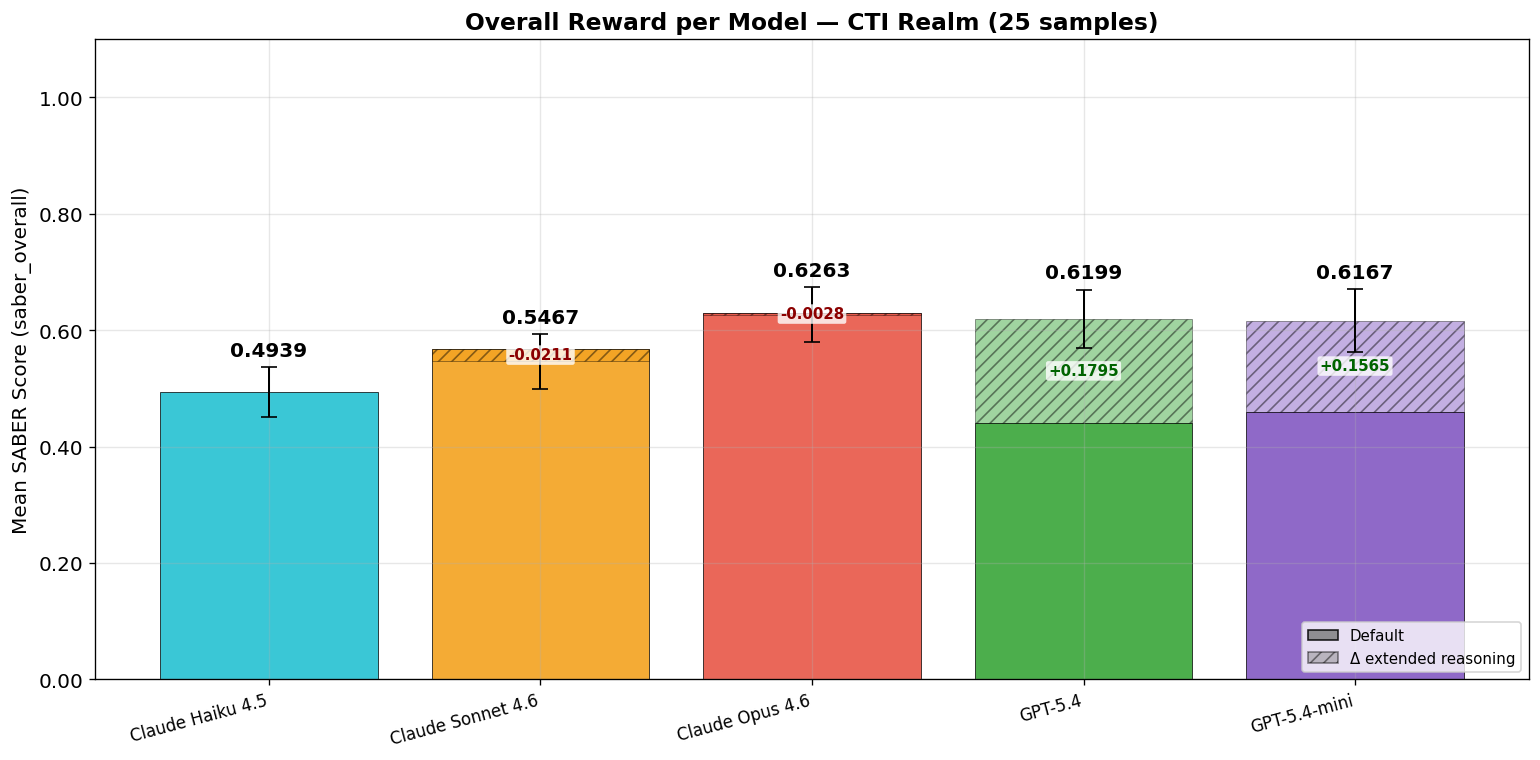

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Overall mean scores
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))
means = [overall_df.loc[m, 'mean'] for m in MODEL_ORDER]
stderrs = [overall_df.loc[m, 'stderr'] for m in MODEL_ORDER]
colors = [COLORS[m] for m in MODEL_ORDER]

base_heights, delta_heights = [], []
for m in MODEL_ORDER:
    if m in no_thinking_overall:
        base_heights.append(no_thinking_overall[m]['mean'])
        delta_heights.append(overall_df.loc[m, 'mean'] - no_thinking_overall[m]['mean'])
    else:
        base_heights.append(overall_df.loc[m, 'mean'])
        delta_heights.append(0.0)

x = np.arange(len(MODEL_ORDER))
ax.bar(x, base_heights, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, m in enumerate(MODEL_ORDER):
    if delta_heights[i] != 0:
        ax.bar(i, abs(delta_heights[i]),
               bottom=base_heights[i] if delta_heights[i] > 0 else base_heights[i] + delta_heights[i],
               color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)
for i, (mean, se) in enumerate(zip(means, stderrs)):
    ax.text(i, mean + se + 0.012, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
for i, m in enumerate(MODEL_ORDER):
    if m in no_thinking_overall:
        d = delta_heights[i]
        ax.text(i, base_heights[i] + d/2, f'{d:+.4f}', ha='center', va='center', fontsize=9, fontweight='bold',
                color='#006400' if d > 0 else '#8B0000',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score (saber_overall)')
ax.set_title(f'Overall Reward per Model — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.10); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(handles=[mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Platform Reward Breakdown (CTI Realm-Specific)

### What this measures

CTI Realm has **3 platforms**, each with distinct telemetry sources, data schemas, and detection patterns: **Linux** (15 tasks), **AKS** (6 tasks), **Cloud** (4 tasks). This analysis uses `GROUP_FN` (mapping sample IDs → platform prefix) to reveal how platform complexity affects model performance.

### How to read the chart

- Each cluster = one platform; bars = models
- Task counts shown below each platform name
- Hatched overlays = reasoning delta per platform
- Large variation within a cluster = model-dependent difficulty
- Uniformly low clusters = platform is inherently hard for all models

### Key question

Are some platforms universally harder, or does each model have unique strengths/weaknesses per platform? Platforms where model rankings change dramatically are the most interesting from a research perspective.

### Key insights (CTI Realm)

- **Platform difficulty has a clear hierarchy**: Linux (avg=0.717) >> AKS (avg=0.429) >> Cloud (avg=0.295)
- **Linux** is the easiest by a wide margin — GPT-5.4-mini (0.798) and GPT-5.4 (0.791) lead, with Opus (0.757) close behind. All models score ≥0.600.
- **AKS** shows moderate difficulty — Opus leads (0.501) and model rankings change, with GPT models (0.387–0.385) falling below Claude family
- **Cloud** is extremely challenging — all models score below 0.33; best is GPT-5.4 (0.328), worst is Haiku (0.239)
- **Model rankings shift across platforms**: GPT models dominate Linux but fall behind Claude on AKS and Cloud, suggesting Claude handles diverse/unfamiliar telemetry schemas better
- Per-platform breakdown:
  - **Linux** (n=15): avg=0.717, best=GPT-5.4-mini (0.798)
  - **AKS** (n=6): avg=0.429, best=Claude Opus 4.6 (0.501)
  - **Cloud** (n=4): avg=0.295, best=GPT-5.4 (0.328)

═══ Per-Platform Mean Scores ═══
model  Claude Haiku 4.5  Claude Sonnet 4.6  Claude Opus 4.6  GPT-5.4  GPT-5.4-mini
group                                                                             
aks              0.3993             0.4716           0.5014   0.3870        0.3848
cloud            0.2393             0.3008           0.3246   0.3277        0.2847
linux            0.5996             0.6423           0.7568   0.7909        0.7980


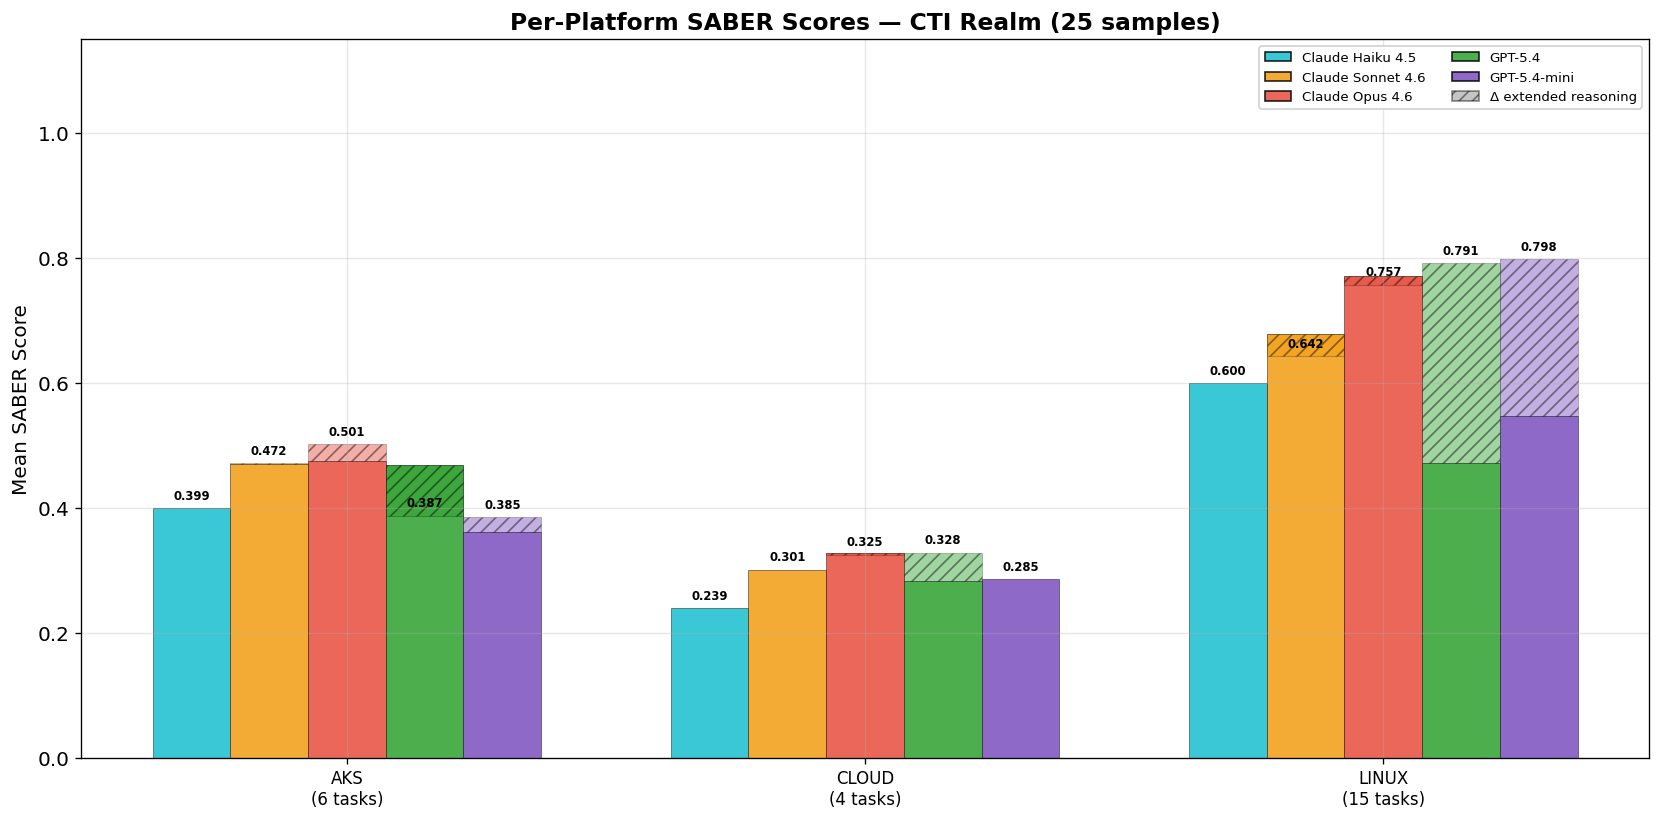

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-platform grouped bar chart
# ══════════════════════════════════════════════════════════════════════════════
group_scores = samples_df.groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER).sort_index()
group_counts = samples_df[samples_df['model'] == MODEL_ORDER[0]].groupby('group').size()

baseline_group = pd.DataFrame()
if len(baseline_samples_df) > 0:
    baseline_group = baseline_samples_df.groupby(['group', 'model'])['score'].mean().unstack('model')
    baseline_group = baseline_group.reindex(index=group_scores.index, columns=MODEL_ORDER)

print(f'═══ Per-{GROUP_LABEL} Mean Scores ═══')
print(group_scores.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 7))
n_groups, n_models = len(group_scores), len(MODEL_ORDER)
bar_width = min(0.15, 0.8 / n_models)
xg = np.arange(n_groups)

for i, model in enumerate(MODEL_ORDER):
    offset = (i - n_models/2 + 0.5) * bar_width
    full_vals = group_scores[model].values
    has_base = model in no_thinking_overall and len(baseline_group) > 0 and model in baseline_group.columns

    if has_base:
        base_vals = baseline_group[model].values
        ax.bar(xg + offset, base_vals, bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.85)
        for xi in range(len(xg)):
            d = full_vals[xi] - base_vals[xi]
            if abs(d) > 0.001:
                ax.bar(xg[xi] + offset, abs(d), bottom=base_vals[xi] if d > 0 else full_vals[xi],
                       width=bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
    else:
        ax.bar(xg + offset, full_vals, bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.85)

    for xi, v in zip(xg, full_vals):
        ax.text(xi + offset, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='black', alpha=0.85, label=m) for m in MODEL_ORDER]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9, ncol=2)
ax.set_xticks(xg)
ax.set_xticklabels([f'{g.upper()}\n({group_counts.get(g, "?")} tasks)' for g in group_scores.index], fontsize=10)
ax.set_ylabel('Mean SABER Score')
ax.set_title(f'Per-Platform SABER Scores — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'per_platform_scores.png', bbox_inches='tight')
plt.show()

---

## 3. Cost Analysis

### What this measures

Quantifies **total cost**, **cost per sample**, and **score-cost tradeoffs** for each model using token counts from eval logs and published API pricing.

### Charts

1. **Total Eval Cost** — absolute dollar cost of the full benchmark run (25 samples)
2. **Cost per Sample** — average cost per task (useful for budgeting)
3. **Score vs. Cost (Pareto)** — upper-left = best value; arrows show the cost of enabling reasoning

### How to read the Pareto chart

- Hollow markers = default mode (no reasoning); filled = with reasoning
- Arrows connect default → reasoning for the same model
- The Pareto frontier (upper-left envelope) shows which models dominate at each cost level

> **To add pricing for your model:** Update `PRICING` in the Configuration cell.

### Key insights (CTI Realm)

- **Claude Haiku 4.5** is the cheapest at $2.43 total ($0.10/sample) — an order of magnitude less than most competitors
- **GPT-5.4** is the most expensive at $123.61 — **51× more** than Claude Haiku 4.5
- The cost spread is enormous: from $2.43 (Haiku) to $123.61 (GPT-5.4), a 51× multiplier for only 26% more score
- Cost ordering: Claude Haiku 4.5 ($2.43) < GPT-5.4-mini ($8.41) < Claude Sonnet 4.6 ($8.99) < Claude Opus 4.6 ($50.85) < GPT-5.4 ($123.61)
- The Pareto frontier shows GPT-5.4-mini offers the best value at mid-tier pricing, while GPT-5.4's marginal score improvement over Opus does not justify its 2.4× cost premium

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3a: Cost extraction
# ══════════════════════════════════════════════════════════════════════════════
cost_df = pd.DataFrame(extract_cost_rows(EVAL_LOGS, LOG_DIR, PRICING, N_SAMPLES)).set_index('model').reindex(MODEL_ORDER)
_baseline_rows = extract_cost_rows(NO_THINKING_LOGS, LOG_DIR, PRICING, N_SAMPLES)
baseline_cost_df = pd.DataFrame(_baseline_rows).set_index('model') if _baseline_rows else pd.DataFrame()

print('═══ Cost (with extended reasoning) ═══')
print(cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
print()
print('═══ Cost (default / no reasoning) ═══')
print(baseline_cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string() if len(baseline_cost_df) > 0 else '(no baseline logs configured)')

═══ Cost (with extended reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Haiku 4.5    0.49        2.43             0.10
Claude Sonnet 4.6   0.55        8.99             0.36
Claude Opus 4.6     0.63       50.85             2.03
GPT-5.4             0.62      123.61             4.94
GPT-5.4-mini        0.62        8.41             0.34

═══ Cost (default / no reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Sonnet 4.6   0.57        9.49             0.38
Claude Opus 4.6     0.63       56.50             2.26
GPT-5.4             0.44       13.82             0.55
GPT-5.4-mini        0.46        1.94             0.08


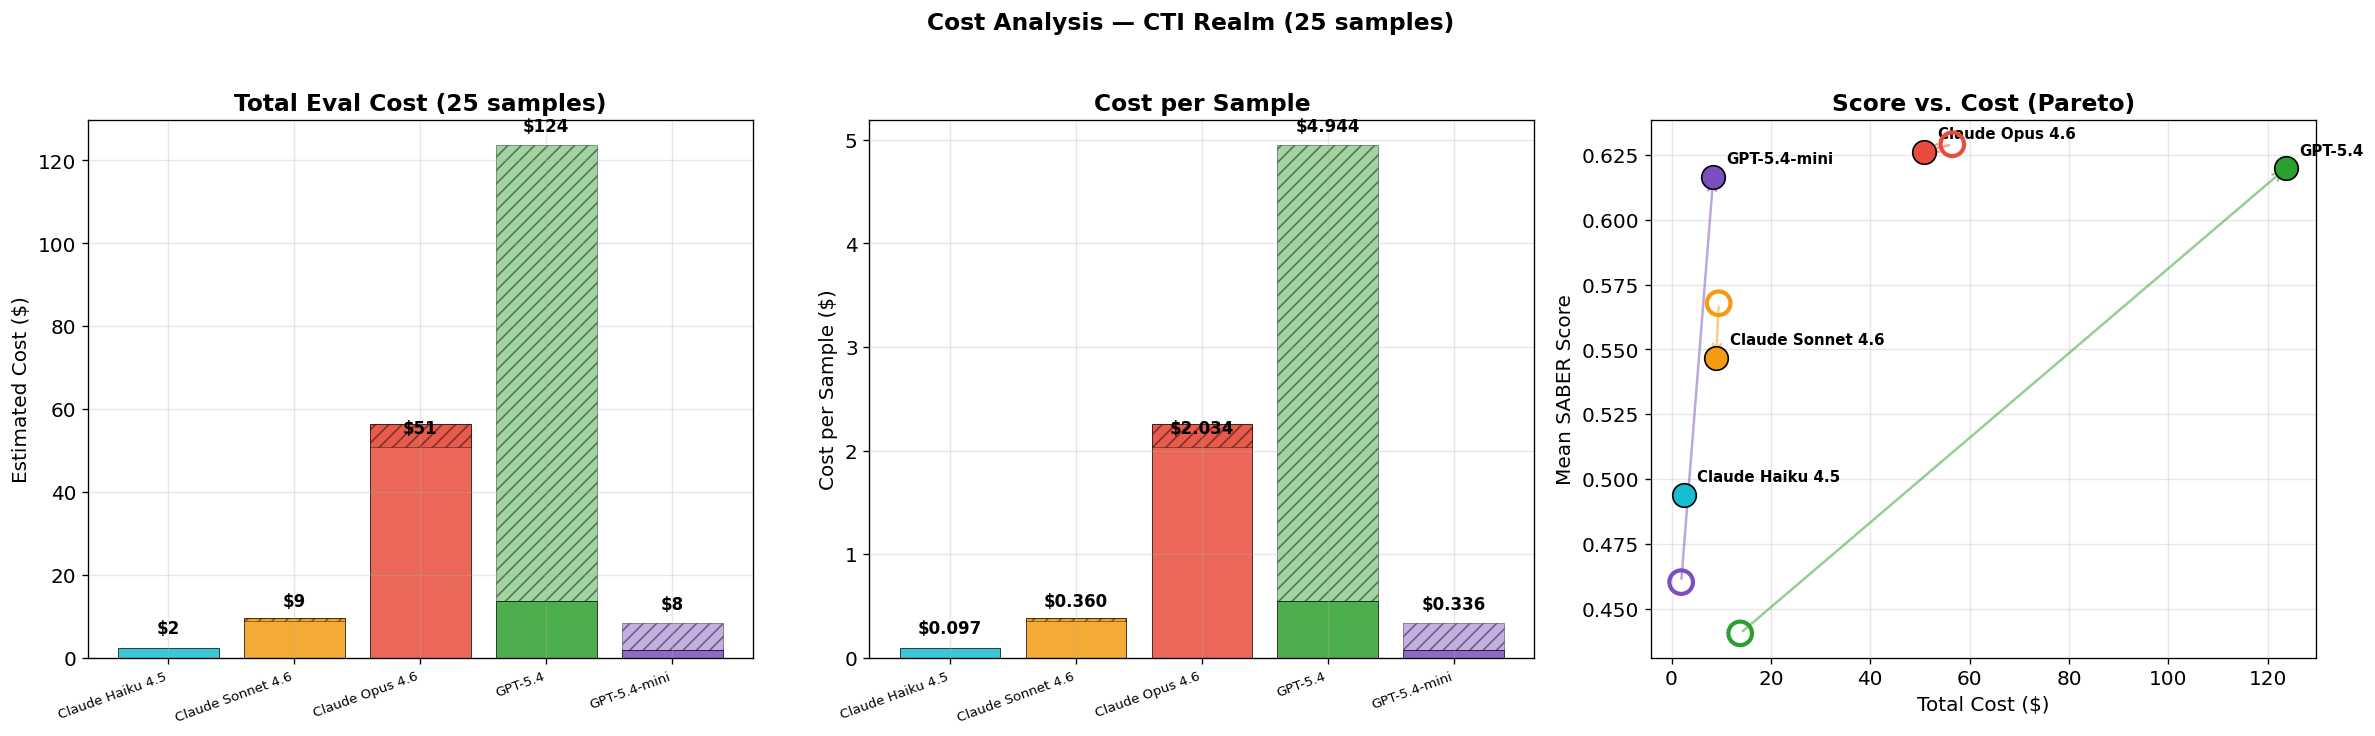

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3b: Cost visualization
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(MODEL_ORDER))

for panel, (col, ylabel, title, fmt) in enumerate([
    ('total_cost', 'Estimated Cost ($)', f'Total Eval Cost ({N_SAMPLES} samples)', '${:.0f}'),
    ('cost_per_sample', 'Cost per Sample ($)', 'Cost per Sample', '${:.3f}'),
]):
    ax = axes[panel]
    for i, m in enumerate(MODEL_ORDER):
        val = cost_df.loc[m, col]
        if m in baseline_cost_df.index:
            base = baseline_cost_df.loc[m, col]
            ax.bar(i, base, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
            d = val - base
            ax.bar(i, abs(d), bottom=base if d > 0 else val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.bar(i, val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.text(i, val + cost_df[col].max()*0.02, fmt.format(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')

ax = axes[2]
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    ax.scatter(row['total_cost'], row['score'], s=200, color=COLORS[m], edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(m, (row['total_cost'], row['score']), textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')
for m in baseline_cost_df.index:
    if m not in COLORS: continue
    brow = baseline_cost_df.loc[m]
    ax.scatter(brow['total_cost'], brow['score'], s=200, facecolors='none', edgecolors=COLORS[m], linewidth=2.5, zorder=4)
    ax.annotate('', xy=(cost_df.loc[m, 'total_cost'], cost_df.loc[m, 'score']), xytext=(brow['total_cost'], brow['score']),
                arrowprops=dict(arrowstyle='->', color=COLORS[m], lw=1.5, alpha=0.5))
ax.set_xlabel('Total Cost ($)'); ax.set_ylabel('Mean SABER Score'); ax.set_title('Score vs. Cost (Pareto)', fontweight='bold')
fig.suptitle(f'Cost Analysis — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_analysis.png', bbox_inches='tight')
plt.show()

---

## 4. Token Usage Breakdown

### What this measures

Decomposes **where tokens are spent** per model: input, output, cache reads/writes, and reasoning tokens.

- **Input** — prompts, tool results, conversation history
- **Output** — model-generated text, tool calls, answers
- **Cache Read/Write** — prompt caching (reduces cost for repeated prefixes)
- **Reasoning** — internal chain-of-thought (extended thinking)

### How to read the chart

- Horizontal stacked bars show the composition of token usage per model
- **Solid segments** = default mode; **Hatched segments** = additional from extended reasoning
- Total token count and default-mode baseline annotated on the right
- Longer bars = more tokens consumed overall; Δ annotations show the reasoning overhead

### Key insights (CTI Realm)

- **GPT-5.4 and GPT-5.4-mini** are the heaviest token consumers at 16.2M and 16.0M respectively — driven by the 70-call tool limit and high reasoning token overhead
- **Claude Sonnet 4.6** is the most token-efficient at 6.2M, yet achieves higher scores than Haiku (7.9M), demonstrating superior token efficiency
- **Claude Opus 4.6** uses 9.0M tokens — more than Sonnet but less than GPT models — positioned as a high-quality mid-token option
- Cache read tokens are significant for Claude models, reflecting prompt caching across the multi-step CTI investigation workflow
- The 2.5× token gap between GPT and Claude models directly correlates with the cost gap — GPT models consume far more tokens per task due to their verbose reasoning style

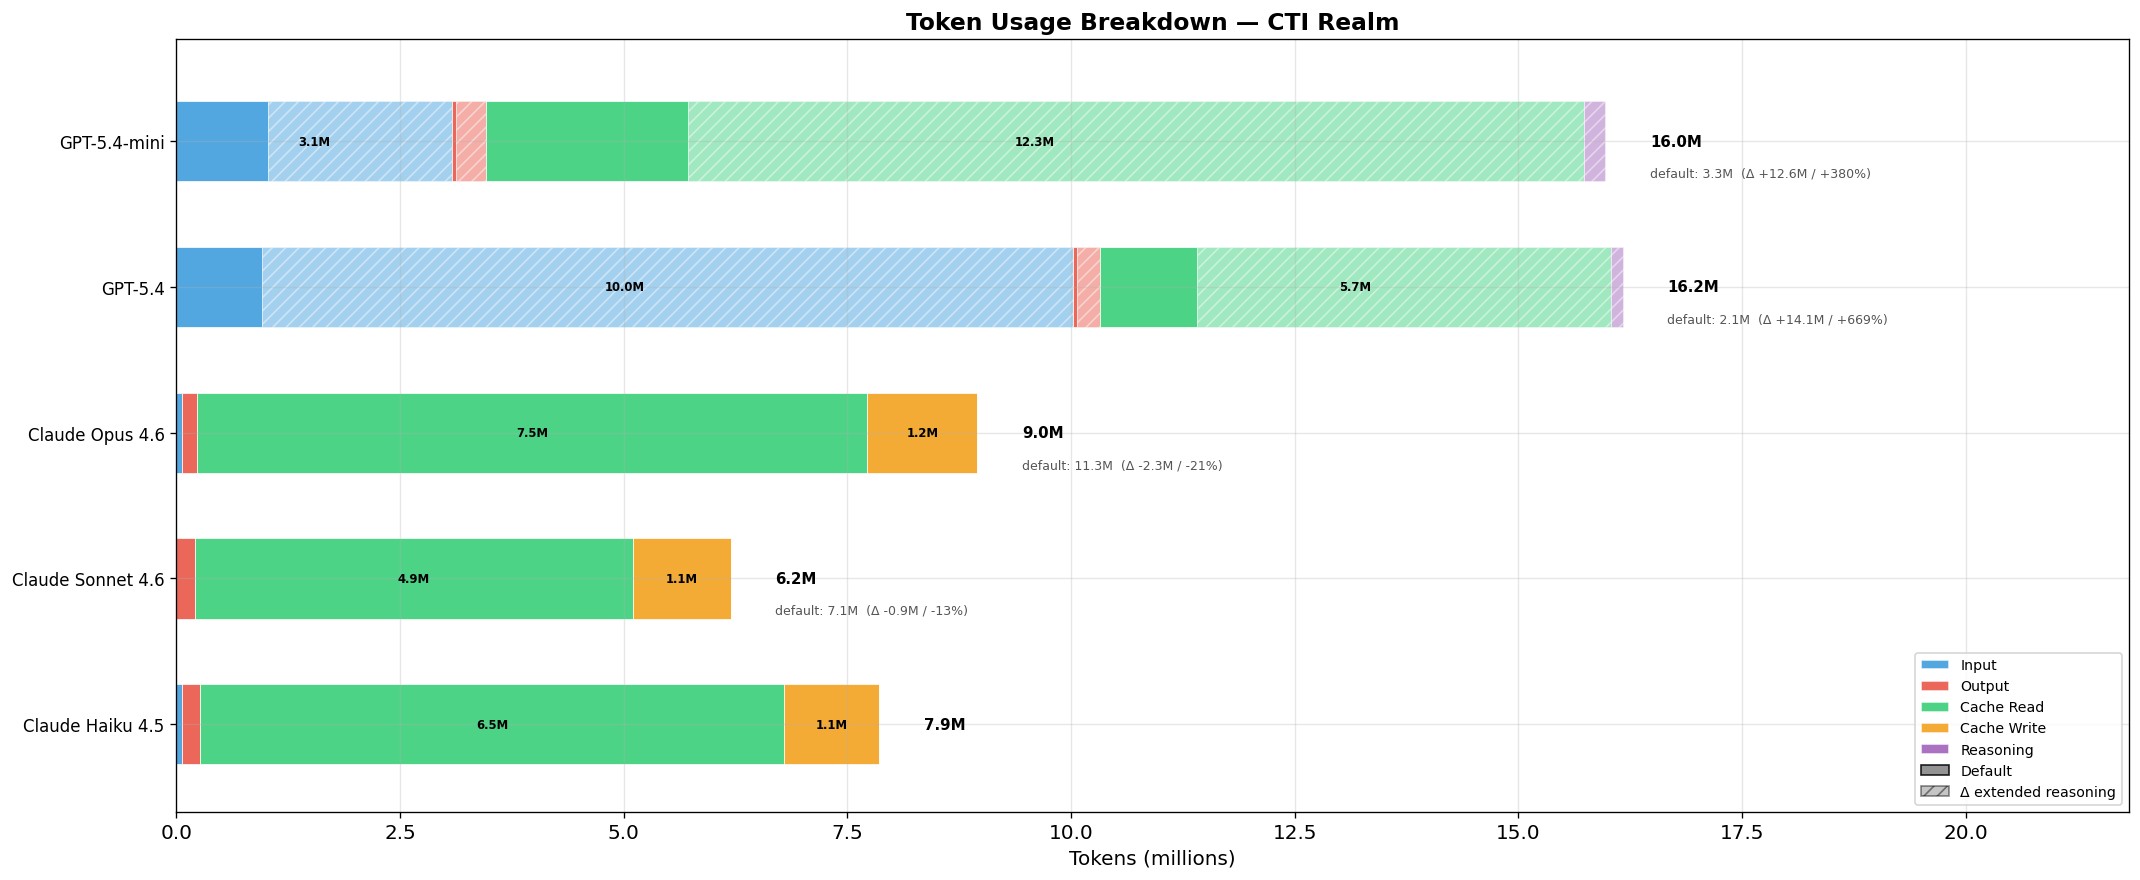

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Token usage stacked horizontal bars
# ══════════════════════════════════════════════════════════════════════════════
categories = ['Input', 'Output', 'Cache Read', 'Cache Write', 'Reasoning']
cat_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
token_keys = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens']

fig, ax = plt.subplots(figsize=(18, 7.5))
bar_height = 0.55
all_totals = [sum(cost_df.loc[m][k]/1e6 for k in token_keys) for m in MODEL_ORDER]
global_max = max(all_totals)
MIN_LABEL_WIDTH = global_max * 0.05

for i, m in enumerate(MODEL_ORDER):
    row = cost_df.loc[m]
    vals = [row[k]/1e6 for k in token_keys]
    has_baseline = m in baseline_cost_df.index
    bvals = [baseline_cost_df.loc[m][k]/1e6 for k in token_keys] if has_baseline else vals

    left = 0
    for j, (rv, bv, c) in enumerate(zip(vals, bvals, cat_colors)):
        if has_baseline and rv > 0:
            solid_w = min(rv, bv)
            ax.barh(i, solid_w, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
            if rv - bv > 0.01:
                ax.barh(i, rv - bv, left=left + solid_w, height=bar_height, color=c,
                        edgecolor='white', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.barh(i, rv, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
        if rv >= MIN_LABEL_WIDTH:
            ax.text(left + rv/2, i, f'{rv:.1f}M', ha='center', va='center', fontsize=7, fontweight='bold')
        left += rv

    ax.text(left + 0.5, i, f'{sum(vals):.1f}M', va='center', ha='left', fontsize=9, fontweight='bold')
    if has_baseline:
        bt = sum(bvals); td = sum(vals) - bt
        ax.text(left + 0.5, i - 0.22, f'default: {bt:.1f}M  (Δ {td:+.1f}M / {td/bt*100:+.0f}%)',
                va='center', ha='left', fontsize=7.5, fontstyle='italic', color='#555')

ax.set_yticks(range(len(MODEL_ORDER))); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_xlabel('Tokens (millions)'); ax.set_title(f'Token Usage Breakdown — {DOMAIN_NAME}', fontweight='bold')
ax.set_xlim(right=global_max * 1.35); ax.set_ylim(-0.6, len(MODEL_ORDER) - 0.3)
legend_handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=cat) for cat, c in zip(categories, cat_colors)]
legend_handles += [mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'token_usage.png', bbox_inches='tight')
plt.show()

---

## 5. Cost Efficiency: Reward per Dollar

$$\text{Cost Efficiency} = \frac{\text{Mean SABER Score}}{\text{Total Cost (\$)}}$$

### What this measures

Higher = better value. The most cost-efficient model is not always the highest-scoring one — for budget-constrained deployments, this metric identifies which model delivers the most benefit per dollar.

### How to read the chart

- **Solid bars** = efficiency in default mode; **Hatched** = delta with reasoning
- Taller bars = better cost efficiency
- Note that reasoning can actually *decrease* cost efficiency if the additional cost outweighs the score improvement

### Key insights (CTI Realm)

- **Claude Haiku 4.5** delivers 0.2036 score per dollar — **41× more efficient** than GPT-5.4 (0.0050)
- Efficiency ranking: Claude Haiku 4.5 (0.2036) >> GPT-5.4-mini (0.0733) > Claude Sonnet 4.6 (0.0608) >> Claude Opus 4.6 (0.0123) > GPT-5.4 (0.0050)
- **GPT-5.4-mini** edges out Sonnet in efficiency despite similar absolute costs, thanks to slightly better score-to-cost ratio on CTI tasks
- GPT-5.4 has the worst cost efficiency by far — highest cost ($123.61) for only marginally lower score than Opus ($50.85), resulting in 2.5× worse efficiency
- Extended reasoning *improves* cost efficiency for GPT models (score improvement outweighs cost increase) but *decreases* it for Claude models

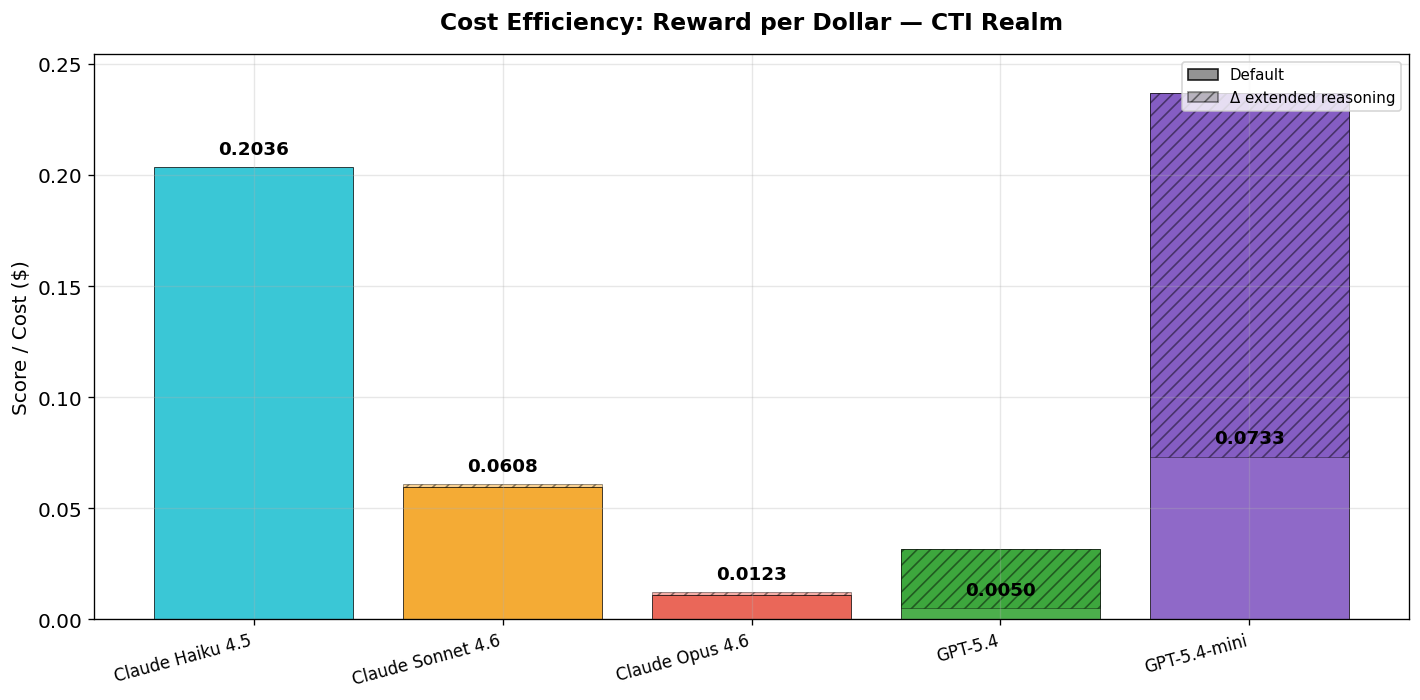

═══ Cost Efficiency Summary ═══
Model                      Score     Cost   $/sample    Score/$
────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.494 $   2.43 $   0.0970    0.20356
Claude Sonnet 4.6          0.547 $   8.99 $   0.3598    0.06078
Claude Opus 4.6            0.626 $  50.85 $   2.0341    0.01232
GPT-5.4                    0.620 $ 123.61 $   4.9443    0.00501
GPT-5.4-mini               0.617 $   8.41 $   0.3365    0.07331


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Cost efficiency
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
rpd = cost_df['score'] / cost_df['total_cost']
base_rpd = baseline_cost_df['score'] / baseline_cost_df['total_cost'] if len(baseline_cost_df) > 0 else pd.Series(dtype=float)

for i, m in enumerate(MODEL_ORDER):
    val = rpd[m]
    if m in base_rpd.index:
        bv = base_rpd[m]
        ax.bar(i, bv, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        d = val - bv
        ax.bar(i, abs(d), bottom=bv if d > 0 else val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, val + rpd.max()*0.02, f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Score / Cost ($)'); ax.set_title(f'Cost Efficiency: Reward per Dollar — {DOMAIN_NAME}', fontweight='bold', pad=15)
ax.set_ylim(0, rpd.max() * 1.25)
ax.legend(handles=[mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Cost":>8s} {"$/sample":>10s} {"Score/$":>10s}')
print('─' * 60)
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    print(f'{m:25s} {row["score"]:6.3f} ${row["total_cost"]:7.2f} ${row["cost_per_sample"]:9.4f} {rpd[m]:10.5f}')

---

## 6. Sub-Task Score Breakdown

### What this measures

CTI Realm tasks have **5 checkpoints** plus an aggregate score, each measuring a different aspect of the threat intelligence workflow:

- **C0: CTI Alignment** (max 1.25) — Did the agent use CTI reports? How relevant were they?
- **C1: MITRE Techniques** (max 0.75) — Jaccard similarity of MITRE techniques found vs. expected
- **C2: Data Exploration** (max 1.0) — Coverage of expected data sources queried
- **C3: Query Iteration** (max 0.5) — Binary: did the agent execute ≥2 unique successful KQL queries?
- **C4: Detection Quality** (max 6.5) — KQL F1 score (5.0 weight) + Sigma rule quality (1.5 weight)

C4 dominates the score (65% of total), making detection quality the primary differentiator between models.

### How to read the chart

- Grouped bars per model: each color = one checkpoint (normalized to fraction of max for fair comparison)
- Values closer to 1.0 = achieving full marks on that checkpoint
- Consistently low bars across all models = universally hard checkpoint

### Key insights (CTI Realm)

- **C3 (Query Iteration)** is the easiest checkpoint — GPT-5.4-mini achieves 100% (0.50/0.50), and Opus/GPT-5.4 hit 92%. This is binary (did the agent run ≥2 queries?) and most models do this reliably.
- **C1 (MITRE Techniques)** shows strong cross-model performance: Sonnet and GPT-5.4 both hit 85%, Haiku 72%. MITRE technique identification is a well-known task category these models handle well.
- **C2 (Data Exploration)** is surprisingly uniform — Haiku leads at 77%, while all others cluster around 66–69%. Haiku's broad exploration strategy helps here despite lower overall scores.
- **C0 (CTI Alignment)** varies the most: Opus leads at 61%, GPT-5.4-mini trails at 44%. This checkpoint measures whether the agent grounds its analysis in relevant CTI reports — a judgment-intensive task.
- **C4 (Detection Quality)** is the most challenging and the primary differentiator: Opus and both GPT models achieve ~59%, Sonnet 49%, Haiku just 42%. Since C4 is 65% of total score, it largely determines overall rankings.
  - **Per-checkpoint scores**:
    - C0 CTI Alignment: Haiku=0.603(48%), Sonnet=0.675(54%), Opus=0.768(61%), GPT-5.4=0.585(47%), GPT-5.4-mini=0.545(44%)
    - C1 MITRE Techniques: Haiku=0.541(72%), Sonnet=0.640(85%), Opus=0.568(76%), GPT-5.4=0.635(85%), GPT-5.4-mini=0.610(81%)
    - C2 Data Exploration: Haiku=0.775(77%), Sonnet=0.663(66%), Opus=0.683(68%), GPT-5.4=0.693(69%), GPT-5.4-mini=0.690(69%)
    - C3 Query Iteration: Haiku=0.300(60%), Sonnet=0.300(60%), Opus=0.460(92%), GPT-5.4=0.460(92%), GPT-5.4-mini=0.500(100%)
    - C4 Detection Quality: Haiku=2.720(42%), Sonnet=3.189(49%), Opus=3.783(58%), GPT-5.4=3.826(59%), GPT-5.4-mini=3.822(59%)

═══ Per-Checkpoint Mean Scores ═══

  C0: CTI Alignment (max=1.25):
    Claude Haiku 4.5           0.6025 / 1.25  (48.2%)
    Claude Sonnet 4.6          0.6750 / 1.25  (54.0%)
    Claude Opus 4.6            0.7685 / 1.25  (61.5%)
    GPT-5.4                    0.5850 / 1.25  (46.8%)
    GPT-5.4-mini               0.5450 / 1.25  (43.6%)

  C1: MITRE Techniques (max=0.75):
    Claude Haiku 4.5           0.5413 / 0.75  (72.2%)
    Claude Sonnet 4.6          0.6398 / 0.75  (85.3%)
    Claude Opus 4.6            0.5681 / 0.75  (75.7%)
    GPT-5.4                    0.6346 / 0.75  (84.6%)
    GPT-5.4-mini               0.6098 / 0.75  (81.3%)

  C2: Data Exploration (max=1.0):
    Claude Haiku 4.5           0.7747 / 1.0  (77.5%)
    Claude Sonnet 4.6          0.6633 / 1.0  (66.3%)
    Claude Opus 4.6            0.6833 / 1.0  (68.3%)
    GPT-5.4                    0.6927 / 1.0  (69.3%)
    GPT-5.4-mini               0.6900 / 1.0  (69.0%)

  C3: Query Iteration (max=0.5):
    Claude Haiku 4.5  

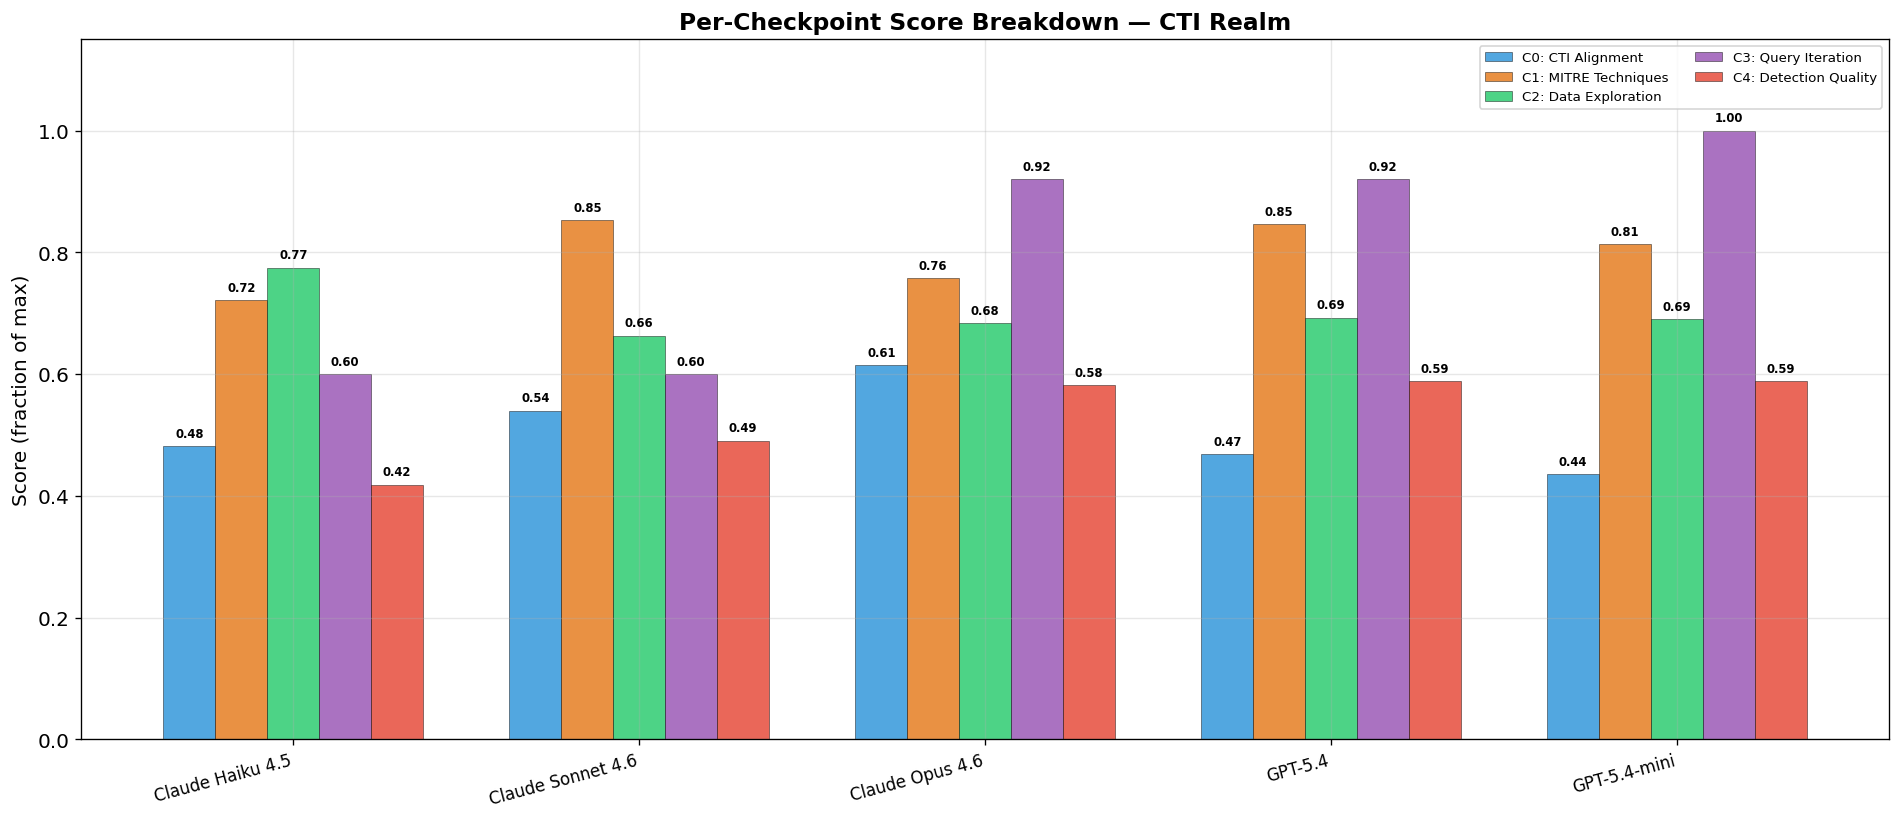

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Sub-task breakdown
# ══════════════════════════════════════════════════════════════════════════════
subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)

# For CTI Realm, show per-checkpoint scores (more informative than Submission/Checkpoints/Aggregate)
checkpoint_means = subtasks_df.groupby(['model', 'score_type'])['score'].mean().unstack('score_type')
checkpoint_means = checkpoint_means.reindex(MODEL_ORDER)

# Filter to actual checkpoint columns (exclude 'aggregate' if present)
cp_cols = [c for c in checkpoint_means.columns if c.startswith('c')]
checkpoint_means = checkpoint_means[cp_cols]

print('═══ Per-Checkpoint Mean Scores ═══')
for col in cp_cols:
    display_name = CHECKPOINT_NAMES.get(col, col)
    max_score = CHECKPOINT_MAX_SCORES.get(col, 1.0)
    print(f'\n  {display_name} (max={max_score}):')
    for m in MODEL_ORDER:
        if col in checkpoint_means.columns:
            raw = checkpoint_means.loc[m, col]
            pct = raw / max_score * 100
            print(f'    {m:25s}  {raw:.4f} / {max_score}  ({pct:.1f}%)')

# Bar chart: per-checkpoint scores grouped by model
fig, ax = plt.subplots(figsize=(16, 7))
cp_plot_colors = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#E74C3C'][:len(cp_cols)]
x = np.arange(len(MODEL_ORDER))
bar_width = 0.15

for j, (col, color) in enumerate(zip(cp_cols, cp_plot_colors)):
    offset = (j - len(cp_cols)/2 + 0.5) * bar_width
    max_s = CHECKPOINT_MAX_SCORES.get(col, 1.0)
    # Normalize to percentage of max for fair comparison
    vals = [checkpoint_means.loc[m, col] / max_s for m in MODEL_ORDER]
    label = CHECKPOINT_NAMES.get(col, col)
    ax.bar(x + offset, vals, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85, label=label)
    for i, v in enumerate(vals):
        ax.text(x[i] + offset, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Score (fraction of max)')
ax.set_title(f'Per-Checkpoint Score Breakdown — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_breakdown.png', bbox_inches='tight')
plt.show()

---

## 7. Checkpoint Score Distributions

### What this measures

Violin plots showing the **full distribution** of each checkpoint score per model. Wide regions = many samples clustered at that score level. One subplot per checkpoint (C0–C4), with the red dashed line showing maximum possible score.

### How to read the chart

- **Bimodal distributions** (two peaks at 0 and max) = pass/fail checkpoint in nature
- **Continuous spread** = fine-grained scoring where models achieve partial credit
- Mean (μ) annotated above each violin
- Wide violins = high variance across samples; narrow = consistent performance

### Key insights (CTI Realm)

- **C3 (Query Iteration)** is the most bimodal — it's binary (0 or 0.5), so violins collapse to two points. Models either pass or fail this threshold.
- **C4 (Detection Quality)** shows the widest continuous distribution, reflecting its multi-criteria scoring (F1 × 5.0 + Sigma × 1.5). All models have samples spanning 0 to ~5.5, with GPT and Opus clusters at higher values.
- **C2 (Data Exploration)** distributions are relatively concentrated — most samples cluster between 0.5 and 1.0 across all models, indicating data schema exploration is consistently achievable.
- **C0 (CTI Alignment)** shows right-skewed distributions where Opus has the highest mean and narrowest spread, suggesting more reliable CTI grounding.
- **C1 (MITRE Techniques)** has moderate spread — the Jaccard similarity metric creates a continuous distribution between 0 and 0.75, with most models centered around 0.5–0.65.

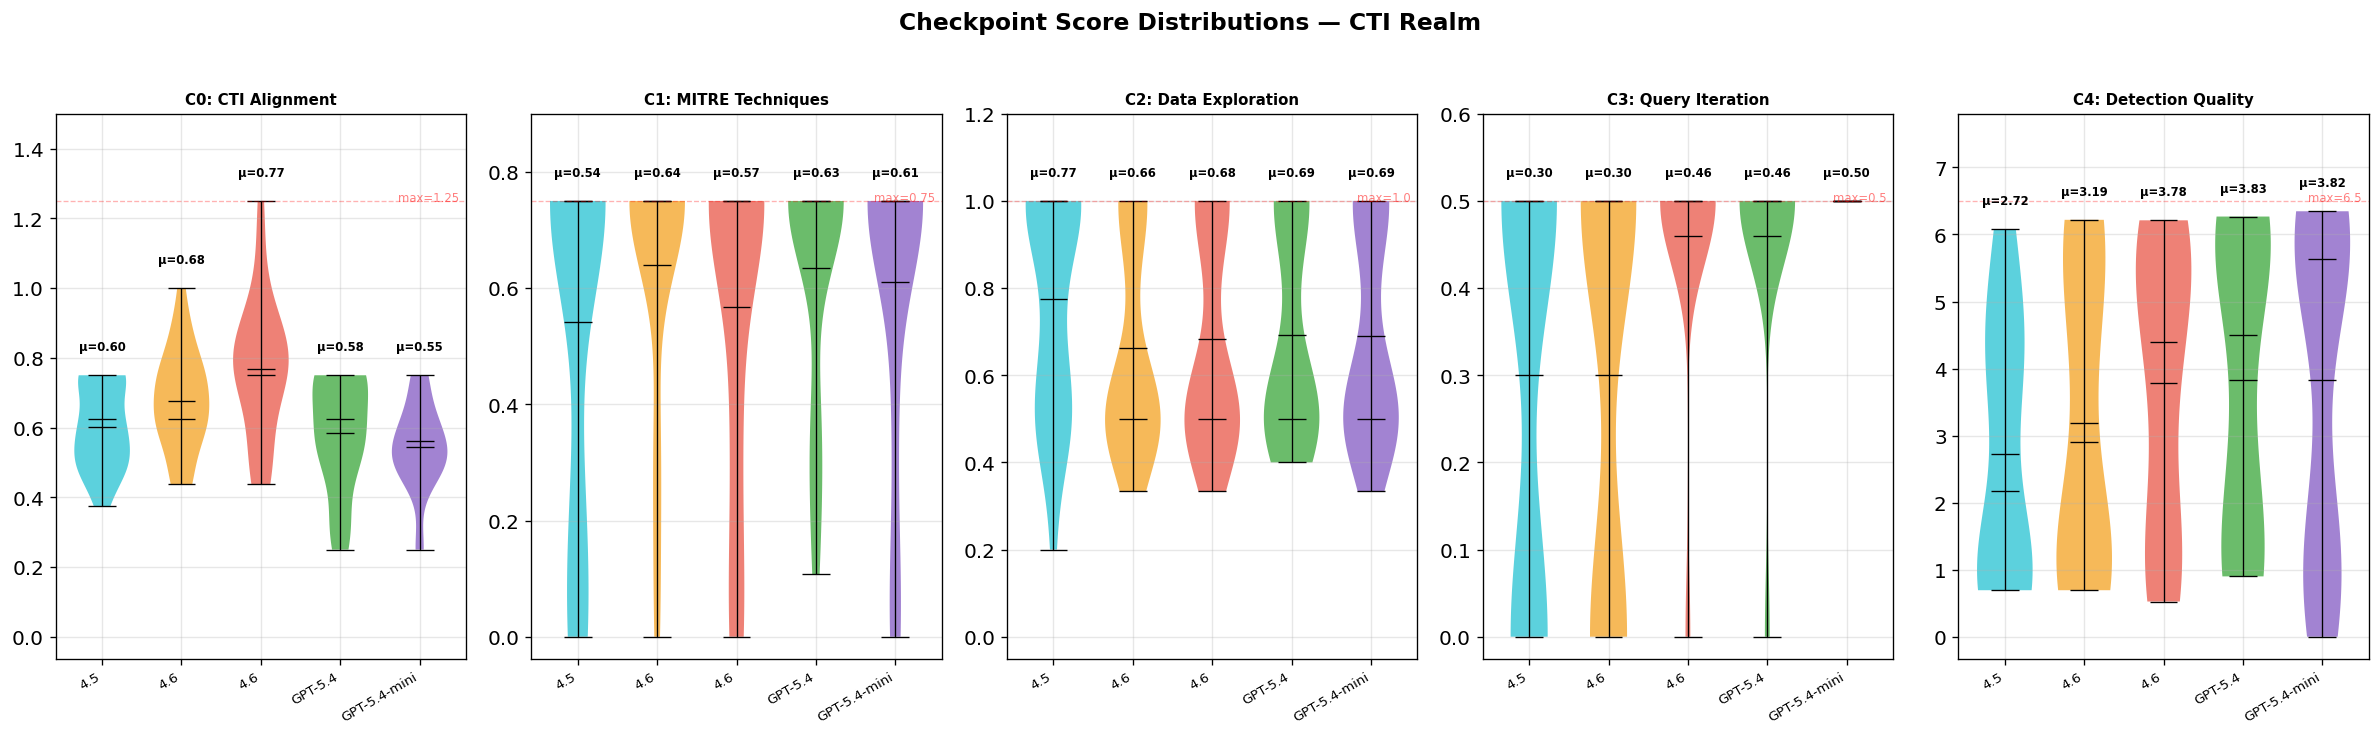

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Checkpoint distributions (violin plot per checkpoint)
# ══════════════════════════════════════════════════════════════════════════════
checkpoint_df = subtasks_df[subtasks_df['score_type'].str.startswith('c')].copy()
cp_types = sorted(checkpoint_df['score_type'].unique())

n_cps = len(cp_types)
fig, axes = plt.subplots(1, n_cps, figsize=(4 * n_cps, 6), sharey=False)
if n_cps == 1:
    axes = [axes]

for ax, cp in zip(axes, cp_types):
    cp_data = checkpoint_df[checkpoint_df['score_type'] == cp]
    max_s = CHECKPOINT_MAX_SCORES.get(cp, 1.0)

    for i, model in enumerate(MODEL_ORDER):
        data = cp_data[cp_data['model'] == model]['score'].values
        if len(data) == 0:
            continue
        vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[model])
            pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor('black')
                vp[part].set_linewidth(0.8)
        ax.text(i, max(data) + max_s * 0.05, f'μ={np.mean(data):.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels([m.split()[-1] for m in MODEL_ORDER], fontsize=8, rotation=30, ha='right')
    ax.set_title(CHECKPOINT_NAMES.get(cp, cp), fontweight='bold', fontsize=9)
    ax.set_ylim(-max_s * 0.05, max_s * 1.2)
    ax.axhline(y=max_s, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.text(len(MODEL_ORDER) - 0.5, max_s, f'max={max_s}', fontsize=7, color='red', alpha=0.5, ha='right')

fig.suptitle(f'Checkpoint Score Distributions — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_distributions.png', bbox_inches='tight')
plt.show()

---

## 8. Per-Checkpoint Score Heatmap (CTI Realm-Specific)

### What this measures

**Model × Checkpoint** heatmap showing normalized scores (fraction of max). This is **unique to CTI Realm** — it visualizes the fine-grained performance profile across the 5-stage detection pipeline, highlighting which checkpoints each model struggles with and whether there's a universal "bottleneck."

### How to read the chart

- **Green cells** = high score (close to max); **Red cells** = low score
- Each cell shows raw score / max and the percentage achieved
- Rows = models; columns = checkpoints (C0–C4)
- The table below shows per-platform × per-checkpoint breakdown for deeper analysis

### Key insights (CTI Realm)

- Since C4 carries 65% of total score, models that excel at C4 rank highest overall — but C0–C3 differentiate models that score similarly on C4
- **C4 (Detection Quality)** is the universal bottleneck: no model exceeds 59% of the maximum (6.5), making KQL query accuracy and Sigma rule quality the primary improvement targets
- **C3 (Query Iteration)** is the universal strength: Opus, GPT-5.4, and GPT-5.4-mini all achieve 92–100%, meaning almost all agents run multiple KQL queries
- **Model-specific patterns**:
  - **Claude Opus 4.6**: Best at C0 (61%) — superior CTI report grounding
  - **Claude Haiku 4.5**: Best at C2 (77%) — broadest data exploration, but worst at C4 (42%)
  - **GPT-5.4 / GPT-5.4-mini**: Best at C4 (59%) and C1 (85%) — strongest at detection writing and MITRE mapping
  - **Claude Sonnet 4.6**: Balanced profile with no standout strength or weakness

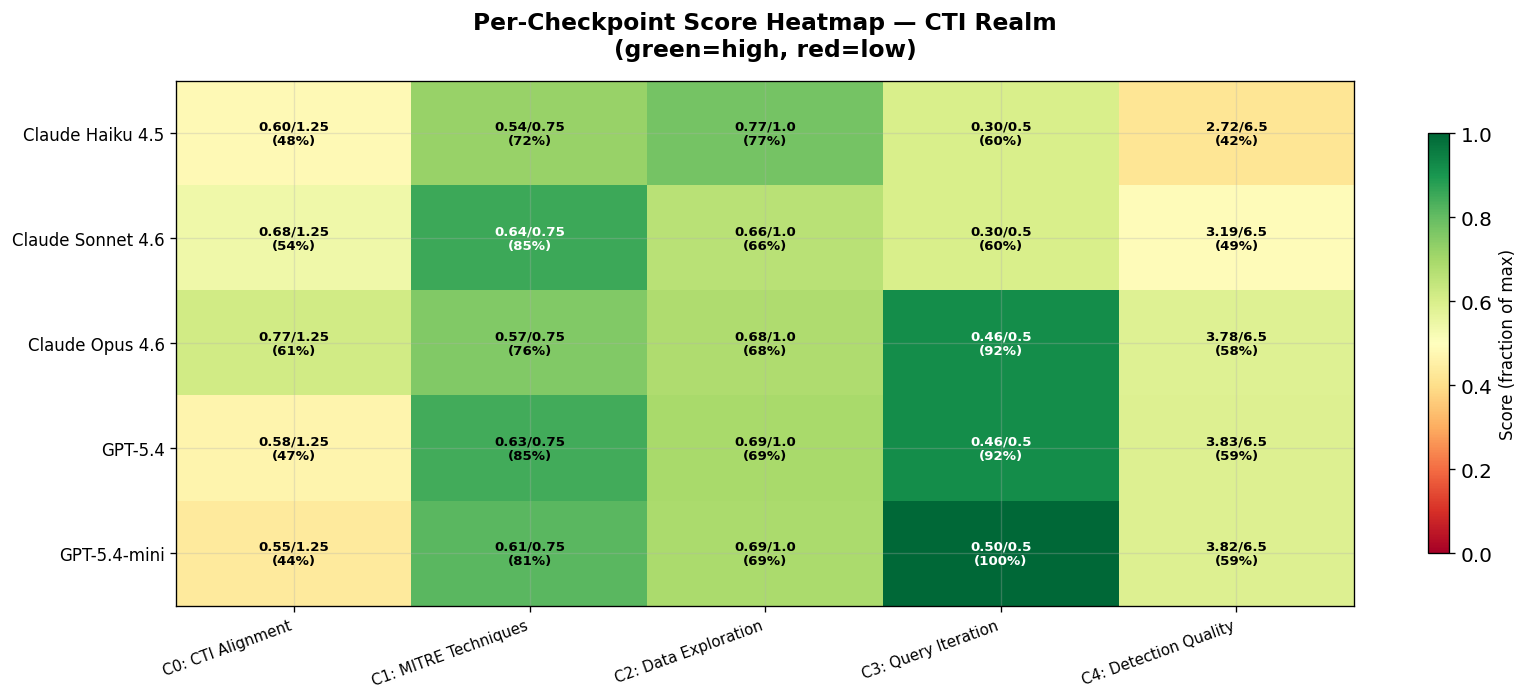


═══ Per-Platform × Checkpoint Mean Scores (normalized) ═══

  Platform: AKS
    C0: CTI Alignment              Claude Haiku 4.5           0.615/1.25  (49%)
    C0: CTI Alignment              Claude Sonnet 4.6          0.656/1.25  (52%)
    C0: CTI Alignment              Claude Opus 4.6            0.719/1.25  (57%)
    C0: CTI Alignment              GPT-5.4                    0.510/1.25  (41%)
    C0: CTI Alignment              GPT-5.4-mini               0.542/1.25  (43%)
    C1: MITRE Techniques           Claude Haiku 4.5           0.625/0.75  (83%)
    C1: MITRE Techniques           Claude Sonnet 4.6          0.750/0.75  (100%)
    C1: MITRE Techniques           Claude Opus 4.6            0.625/0.75  (83%)
    C1: MITRE Techniques           GPT-5.4                    0.750/0.75  (100%)
    C1: MITRE Techniques           GPT-5.4-mini               0.625/0.75  (83%)
    C2: Data Exploration           Claude Haiku 4.5           0.917/1.0  (92%)
    C2: Data Exploration           Claude 

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8 (CTI REALM-SPECIFIC): Per-checkpoint score heatmap
# ══════════════════════════════════════════════════════════════════════════════
# Build matrix: rows=models, columns=checkpoints, values=mean score / max_score
cp_cols_ordered = sorted(CHECKPOINT_NAMES.keys())
heatmap_data = pd.DataFrame(index=MODEL_ORDER, columns=cp_cols_ordered, dtype=float)

for m in MODEL_ORDER:
    m_sub = subtasks_df[subtasks_df['model'] == m]
    for cp in cp_cols_ordered:
        cp_scores = m_sub[m_sub['score_type'] == cp]['score']
        if len(cp_scores) > 0:
            max_s = CHECKPOINT_MAX_SCORES.get(cp, 1.0)
            heatmap_data.loc[m, cp] = cp_scores.mean() / max_s

fig, ax = plt.subplots(figsize=(14, 6))
data = heatmap_data.values.astype(float)
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Labels
cp_labels = [CHECKPOINT_NAMES.get(cp, cp) for cp in cp_cols_ordered]
ax.set_xticks(range(len(cp_cols_ordered)))
ax.set_xticklabels(cp_labels, fontsize=9, rotation=20, ha='right')
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER, fontsize=10)

# Annotate cells with raw score and normalized percentage
for i, m in enumerate(MODEL_ORDER):
    for j, cp in enumerate(cp_cols_ordered):
        val = heatmap_data.loc[m, cp]
        raw_mean = subtasks_df[(subtasks_df['model'] == m) & (subtasks_df['score_type'] == cp)]['score'].mean()
        max_s = CHECKPOINT_MAX_SCORES.get(cp, 1.0)
        if not np.isnan(val):
            text_color = 'white' if val < 0.3 or val > 0.85 else 'black'
            ax.text(j, i, f'{raw_mean:.2f}/{max_s}\n({val:.0%})',
                    ha='center', va='center', fontsize=8, fontweight='bold', color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Score (fraction of max)', fontsize=10)
ax.set_title(f'Per-Checkpoint Score Heatmap — {DOMAIN_NAME}\n(green=high, red=low)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_heatmap.png', bbox_inches='tight')
plt.show()

# Also show per-platform × checkpoint breakdown
print('\n═══ Per-Platform × Checkpoint Mean Scores (normalized) ═══')
for platform in sorted(samples_df['group'].unique()):
    print(f'\n  Platform: {platform.upper()}')
    platform_samples = samples_df[samples_df['group'] == platform]['sample_id'].unique()
    for cp in cp_cols_ordered:
        max_s = CHECKPOINT_MAX_SCORES.get(cp, 1.0)
        cp_label = CHECKPOINT_NAMES.get(cp, cp)
        for m in MODEL_ORDER:
            cp_scores = subtasks_df[
                (subtasks_df['model'] == m) &
                (subtasks_df['score_type'] == cp) &
                (subtasks_df['sample_id'].isin(platform_samples))
            ]['score']
            if len(cp_scores) > 0:
                avg = cp_scores.mean()
                print(f'    {cp_label:30s} {m:25s}  {avg:.3f}/{max_s}  ({avg/max_s:.0%})')

---

## 9. Agent Trajectory Analysis

### What this measures

Analyses 9–13 examine the **behavioral patterns** of the agent — how many tool calls it makes, which tools it uses, how efficiently it spends time, and whether more effort correlates with better scores.

This cell loads per-sample trajectory data: steps (assistant turns), tool calls, and timing from each eval log. CTI Realm agents have access to **11 tools**: bash, python, execute_kql_query, list_kusto_tables, get_table_schema, sample_table_data, list_cti_report_tags, get_cti_reports_by_tag, search_mitre_techniques, search_sigma_rules, validate_output_json.

### Key metrics loaded

- **n_tool_calls** — actual tool invocations (capped at 70 in CTI Realm, vs. 25 in Excytin)
- **n_steps** — assistant message turns (can exceed tool call limit since some turns don't use tools)
- **tool_counts** — per-tool breakdown across all 11 available tools
- **total_time** — wall-clock seconds per sample

### Key insights (CTI Realm)

- **125 trajectory samples** loaded across 5 models (25 per model)
- **GPT models use dramatically more tool calls**: GPT-5.4 (25.2 ± 11.0) and GPT-5.4-mini (23.7 ± 11.3) vs. Claude Haiku (15.3 ± 4.0) and Sonnet (15.6 ± 5.4). GPT models use the 70-call budget more aggressively.
- **Claude Opus 4.6** sits in between at 18.4 ± 5.4 calls — using more than Haiku/Sonnet but far less than GPT
- **GPT models are much slower**: GPT-5.4 (10.1 min/sample) and GPT-5.4-mini (10.8 min/sample) vs. Claude Haiku (1.9 min) and Opus (2.7 min) — a **4–5× latency difference**
- 11 tools observed, reflecting CTI Realm's rich multi-tool investigation workflow (vs. Excytin's 2 tools)

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAJECTORY DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

traj_df = load_trajectory_data(EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN)

# Normalize tool names to lowercase
traj_df['tool_counts'] = traj_df['tool_counts'].apply(
    lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
)

# Flatten tool_counts dicts into separate columns per tool
all_tools = sorted({t for tc in traj_df['tool_counts'] for t in tc})
for tool in all_tools:
    traj_df[f'tool_{tool}'] = traj_df['tool_counts'].apply(lambda d, t=tool: d.get(t, 0))

print(f'✓ Loaded trajectory data: {len(traj_df)} samples × {traj_df["model"].nunique()} models')
print(f'  Tools observed: {all_tools}')
print()
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    print(f'  {m:25s}  steps={mdf.n_steps.mean():.1f}±{mdf.n_steps.std():.1f}  '
          f'tool_calls={mdf.n_tool_calls.mean():.1f}±{mdf.n_tool_calls.std():.1f}  '
          f'time={mdf.total_time.mean():.0f}s±{mdf.total_time.std():.0f}s')

✓ Loaded trajectory data: 125 samples × 5 models
  Tools observed: ['bash', 'execute_kql_query', 'get_cti_reports_by_tag', 'get_table_schema', 'list_cti_report_tags', 'list_kusto_tables', 'python', 'sample_table_data', 'search_mitre_techniques', 'search_sigma_rules', 'validate_output_json']

  Claude Haiku 4.5           steps=11.2±3.1  tool_calls=15.3±4.0  time=117s±29s
  Claude Sonnet 4.6          steps=7.9±3.1  tool_calls=15.6±5.4  time=181s±83s
  Claude Opus 4.6            steps=10.9±2.7  tool_calls=18.4±5.4  time=161s±50s
  GPT-5.4                    steps=14.0±4.8  tool_calls=25.2±11.0  time=605s±399s
  GPT-5.4-mini               steps=14.7±6.3  tool_calls=23.7±11.3  time=650s±753s


### 9a. Mean Score vs. Tool-Call Limit — What's the Optimal Budget?

For each tool-call limit N on the x-axis, compute the mean score across **all samples**, where samples that needed > N tool calls get score 0 (wouldn't have finished under that budget). This shows where returns from allowing more tool calls diminish.

- **Steeper early rise** = model solves many tasks quickly (efficient)
- **Plateau** = increasing the budget further yields diminishing returns
- Curves converge to each model's actual mean score at the real tool-call cap (70)

### Key insights (CTI Realm)

- Claude models reach **95% of their final score** by 20–24 calls: Haiku at 20, Sonnet at 22, Opus at 24. These models are efficient — they rarely need more than 25 calls.
- GPT models need significantly more budget: GPT-5.4 reaches 95% at **33 calls**, GPT-5.4-mini at **35 calls** — using roughly half the 70-call budget before reaching near-peak performance.
- The **Claude vs. GPT split** in budget utilisation is stark: Claude models plateau by call 25 while GPT models continue climbing until call 35+, suggesting GPT's verbose reasoning style requires more iterative tool use.
- CTI Realm's 70-call limit appears well-calibrated — all models plateau well before the cap, though 40 calls would have been sufficient as a tighter limit.

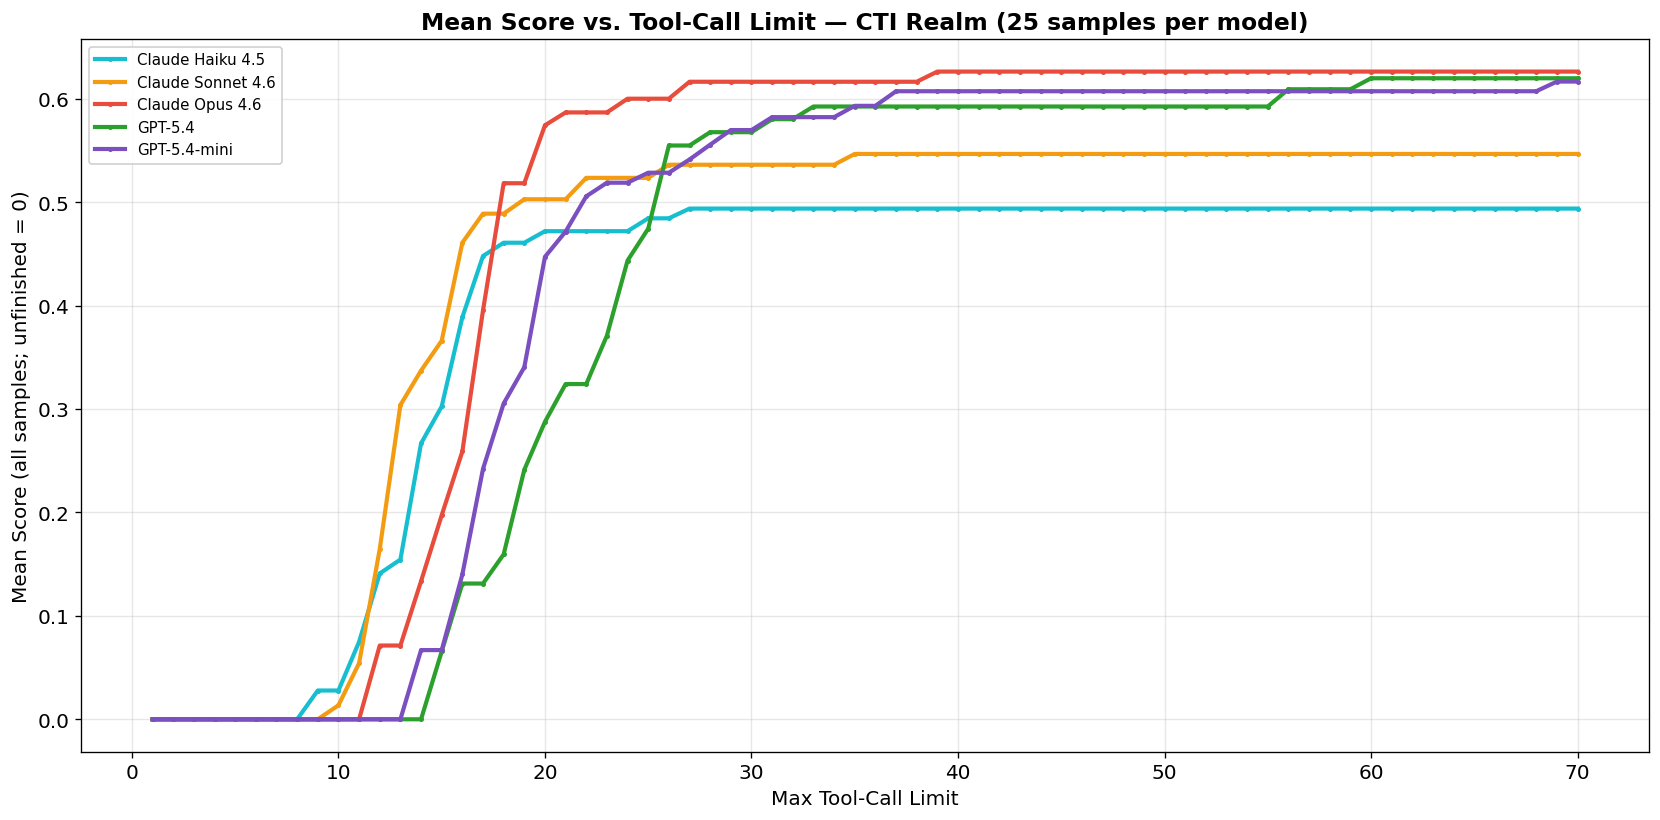

═══ Tool-Call Limit Analysis ═══
  Claude Haiku 4.5           95% at 20 calls  (full=0.4939)
  Claude Sonnet 4.6          95% at 22 calls  (full=0.5467)
  Claude Opus 4.6            95% at 24 calls  (full=0.6263)
  GPT-5.4                    95% at 33 calls  (full=0.6199)
  GPT-5.4-mini               95% at 35 calls  (full=0.6167)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9a: Mean Score vs. Max Tool-Call Limit
# ══════════════════════════════════════════════════════════════════════════════
step_lookup = traj_df[['model', 'sample_id', 'n_tool_calls']].copy()
merged = subtasks_df.merge(step_lookup, on=['model', 'sample_id'], how='inner')
if 'category' not in merged.columns:
    merged['category'] = merged['score_type'].apply(classify_score_type)

call_limits = list(range(1, TOOL_CALL_LIMIT + 1))

fig, ax = plt.subplots(figsize=(14, 7))
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m].copy()
    total_samples = len(mdf)
    means = []
    for limit in call_limits:
        completed = mdf[mdf['n_tool_calls'] <= limit]
        avg = completed['score'].sum() / total_samples if total_samples > 0 else 0
        means.append(avg)
    ax.plot(call_limits, means, color=COLORS[m], linewidth=2.5, marker='o', markersize=2, label=m, zorder=5)

ax.set_xlabel('Max Tool-Call Limit')
ax.set_ylabel('Mean Score (all samples; unfinished = 0)')
ax.set_title(f'Mean Score vs. Tool-Call Limit — {DOMAIN_NAME} ({N_SAMPLES} samples per model)', fontweight='bold')
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'score_vs_tool_call_limit.png', bbox_inches='tight')
plt.show()

# Summary: at what tool-call limit does each model reach 95% of its final score?
print('═══ Tool-Call Limit Analysis ═══')
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    total = len(mdf)
    full_score = mdf['score'].mean()
    target = full_score * 0.95
    limit_95 = TOOL_CALL_LIMIT
    for limit in call_limits:
        avg = mdf[mdf['n_tool_calls'] <= limit]['score'].sum() / total
        if avg >= target:
            limit_95 = limit
            break
    print(f'  {m:25s}  95% at {limit_95:2d} calls  (full={full_score:.4f})')

### 9b. Effort Distribution per Model

How many tool calls and steps does each model use per task? Violin plots show the full distribution.

- **Narrow, low** = efficient (solves tasks quickly)
- **Wide, high** = variable or struggling (many tasks need lots of calls)
- **Long upper tail** = some tasks cause the agent to max out its tool-call budget

### Key insights (CTI Realm)

- **GPT-5.4 and GPT-5.4-mini** have the widest distributions and highest means (25.2 and 23.7 tool calls), with very high variance (σ=11.0 and 11.3). Some tasks drive them close to the 70-call limit.
- **Claude Haiku 4.5** (15.3 ± 4.0) and **Claude Sonnet 4.6** (15.6 ± 5.4) are the most compact — narrower distributions indicate consistent effort across tasks.
- **Claude Opus 4.6** (18.4 ± 5.4) sits in the middle — more thorough than Haiku/Sonnet but more disciplined than GPT models.
- The **step count** (assistant turns) tells a complementary story: GPT models average 14–15 steps vs. Claude's 8–11, meaning GPT models not only invoke more tools but also have more conversational turns per task.
- Unlike Excytin (where Haiku used the most calls), CTI Realm's richer tool ecosystem leads GPT models to be the most prolific — they heavily use KQL data exploration tools.

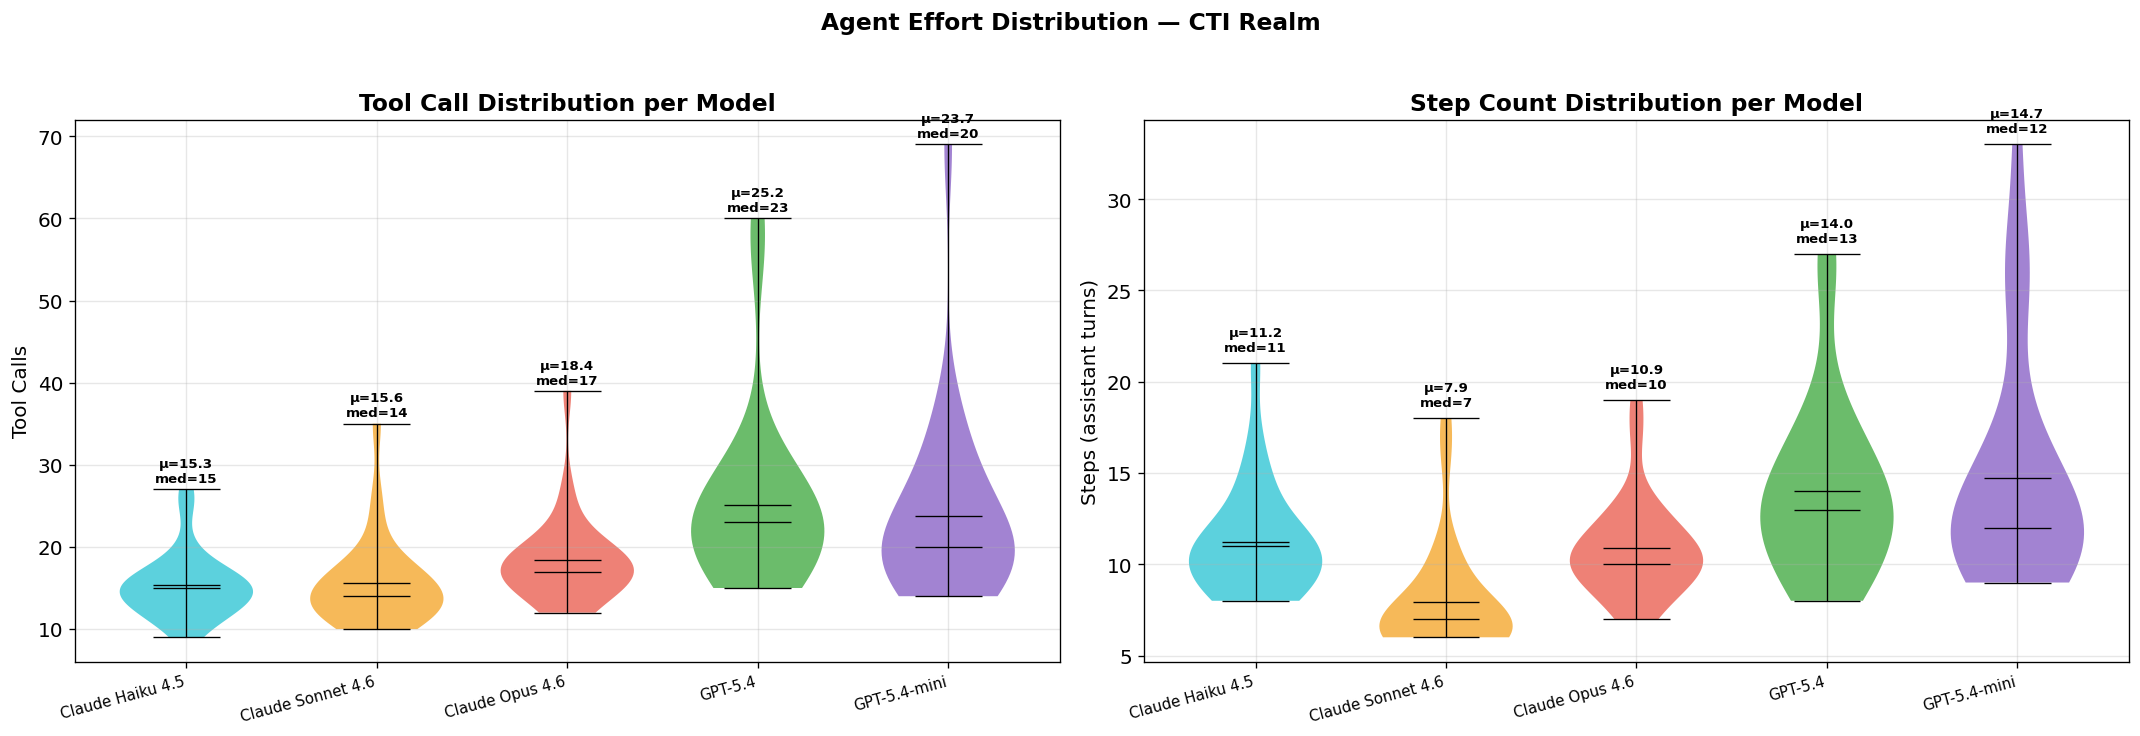

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9b: Tool call & step count distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, metric, ylabel, title in [
    (axes[0], 'n_tool_calls', 'Tool Calls', 'Tool Call Distribution per Model'),
    (axes[1], 'n_steps', 'Steps (assistant turns)', 'Step Count Distribution per Model'),
]:
    for i, m in enumerate(MODEL_ORDER):
        data = traj_df[traj_df['model'] == m][metric].values
        vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[m]); pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp: vp[part].set_edgecolor('black'); vp[part].set_linewidth(0.8)
        ax.text(i, data.max() + 0.5, f'μ={np.mean(data):.1f}\nmed={np.median(data):.0f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')

fig.suptitle(f'Agent Effort Distribution — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'effort_distributions.png', bbox_inches='tight')
plt.show()

### 10. Tool Usage Analysis

### What this measures

How each model allocates its tool calls across CTI Realm's **4 tool categories**:

| Category | Tools | Purpose |
|----------|-------|---------|
| **KQL / Data** | `execute_kql_query`, `list_kusto_tables`, `get_table_schema`, `sample_table_data` | Data exploration & detection writing |
| **CTI / MITRE** | `list_cti_report_tags`, `get_cti_reports_by_tag`, `search_mitre_techniques` | Intelligence gathering & technique mapping |
| **Sigma / Detection** | `search_sigma_rules`, `validate_output_json` | Detection rule discovery & output validation |
| **General** | `bash`, `python` | General-purpose scripting |

### How to read the chart

- **Left panel**: Stacked bars showing absolute tool call counts per model per category
- **Right panel**: Pie chart showing overall distribution across all models — which category gets the most attention?

### Key insights (CTI Realm)

- **KQL / Data dominates**: ~48% of all tool calls across all models go to data exploration tools — agents spend nearly half their effort querying and understanding the data.
- **CTI / MITRE is the second-largest category** (~29%) — intelligence gathering is a core part of the workflow for all models.
- **GPT-5.4 has the heaviest KQL usage** (349 calls) — nearly 2× Claude Opus (205) and more than 2× Haiku (160). GPT models are prolific data explorers.
- **Claude Sonnet 4.6 never uses bash or python** (0 General calls) — it works entirely through the domain-specific MCP tools, the purest tool-use model in the evaluation.
- **Sigma / Detection** varies significantly: Opus leads (116 calls) vs. Haiku (56) — Opus invests more in searching for existing Sigma rules and validating outputs.
- Tool usage per model:
  - **Haiku**: KQL=160, CTI=121, Sigma=56, General=46 (total=383)
  - **Sonnet**: KQL=178, CTI=131, Sigma=81, General=0 (total=390)
  - **Opus**: KQL=205, CTI=130, Sigma=116, General=9 (total=460)
  - **GPT-5.4**: KQL=349, CTI=177, Sigma=76, General=27 (total=629)
  - **GPT-5.4-mini**: KQL=293, CTI=166, Sigma=102, General=32 (total=593)

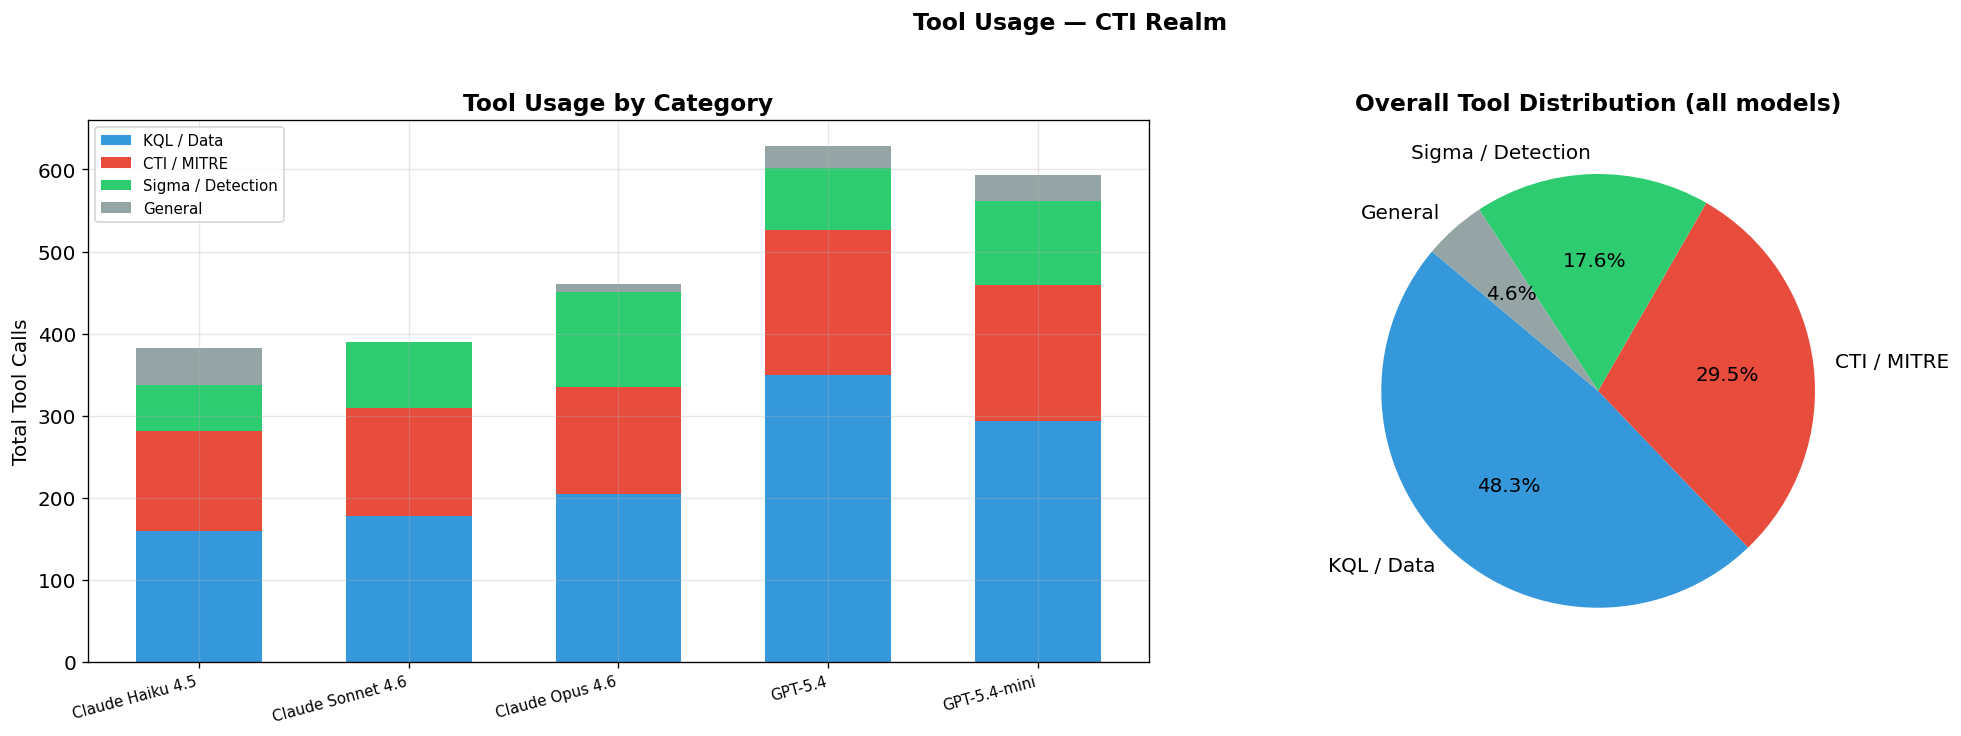


Tool Usage Summary:
Model                     KQL / Data         CTI / MITRE        Sigma / Detection  General               Total
────────────────────────────────────────────────────────────────────────────────────────────────────
Claude Haiku 4.5          160                121                56                 46                      383
Claude Sonnet 4.6         178                131                81                 0                       390
Claude Opus 4.6           205                130                116                9                       460
GPT-5.4                   349                177                76                 27                      629
GPT-5.4-mini              293                166                102                32                      593


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 10: Tool usage breakdown
# ══════════════════════════════════════════════════════════════════════════════
TOOL_CATEGORIES = {
    'KQL / Data':      ['execute_kql_query', 'list_kusto_tables', 'get_table_schema', 'sample_table_data'],
    'CTI / MITRE':     ['list_cti_report_tags', 'get_cti_reports_by_tag', 'search_mitre_techniques'],
    'Sigma / Detection': ['search_sigma_rules', 'validate_output_json'],
    'General':         ['bash', 'python'],
}
CAT_COLORS = {'KQL / Data': '#3498db', 'CTI / MITRE': '#e74c3c', 'Sigma / Detection': '#2ecc71', 'General': '#95a5a6'}

# Count tool calls per model per category using traj_df tool columns
tool_usage = {}
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    counts = {cat: 0 for cat in TOOL_CATEGORIES}
    total = 0
    for cat, tools in TOOL_CATEGORIES.items():
        for t in tools:
            col = f'tool_{t}'
            if col in mdf.columns:
                counts[cat] += int(mdf[col].sum())
                total += int(mdf[col].sum())
    tool_usage[m] = {**counts, 'total': total}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: stacked bar chart of category counts
x = np.arange(len(MODEL_ORDER)); width = 0.6
bottoms = np.zeros(len(MODEL_ORDER))
for cat in TOOL_CATEGORIES:
    vals = [tool_usage.get(m, {}).get(cat, 0) for m in MODEL_ORDER]
    axes[0].bar(x, vals, width, bottom=bottoms, label=cat, color=CAT_COLORS[cat])
    bottoms += vals
axes[0].set_xticks(x); axes[0].set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
axes[0].set_ylabel('Total Tool Calls'); axes[0].set_title('Tool Usage by Category', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: per-model pie chart summary (% per category)
cat_totals = {cat: sum(tool_usage.get(m, {}).get(cat, 0) for m in MODEL_ORDER)
              for cat in TOOL_CATEGORIES}
nonzero = {k: v for k, v in cat_totals.items() if v > 0}
if nonzero:
    axes[1].pie(nonzero.values(), labels=nonzero.keys(), autopct='%1.1f%%',
                colors=[CAT_COLORS[c] for c in nonzero], startangle=140)
    axes[1].set_title('Overall Tool Distribution (all models)', fontweight='bold')

fig.suptitle(f'Tool Usage — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'tool_usage.png', bbox_inches='tight')
plt.show()

# Print summary table
print("\nTool Usage Summary:")
print(f"{'Model':<25} " + " ".join(f"{cat:<18}" for cat in TOOL_CATEGORIES) + f" {'Total':>8}")
print("─" * 100)
for m in MODEL_ORDER:
    u = tool_usage.get(m, {})
    print(f"{m:<25} " + " ".join(f"{u.get(cat,0):<18}" for cat in TOOL_CATEGORIES) + f" {u.get('total',0):>8}")

### 11. Time Efficiency & Reward Per Tool Call

### What this measures

Two dimensions of agent efficiency:

1. **Reward per tool call** — how much score does each model earn per unit of effort?
   $\text{Reward/Call} = \frac{\text{Mean SABER Score}}{\text{Mean Tool Calls}}$

2. **Score vs. Effort scatter** — each dot is one sample; reveals whether more tool calls correlate with better scores

A model with high reward/call is "efficient" — it doesn't waste tool invocations on unproductive exploration.

### Key insights (CTI Realm)

- **Claude Sonnet 4.6** is the most efficient by reward/call (0.0350) — highest score gain per tool invocation, despite using fewer calls than GPT models.
- **Claude Opus 4.6** is close behind (0.0340) with the best reward/minute (0.234), combining strong scores with fast inference.
- **GPT-5.4** has the lowest reward/call (0.0246) — it uses the most tool calls (25.2 avg) but doesn't proportionally convert them into score. Its reward/minute (0.062) is the worst, driven by 10.1 min average inference time.
- **Claude Haiku 4.5** has similar reward/call (0.0322) to Opus despite much lower scores, because it also uses fewer calls — it's efficient per call but limited by its capability ceiling.
- The scatter plot reveals that **higher effort does not guarantee higher scores** — GPT models have many high-effort, low-score samples, while Claude models cluster more efficiently.

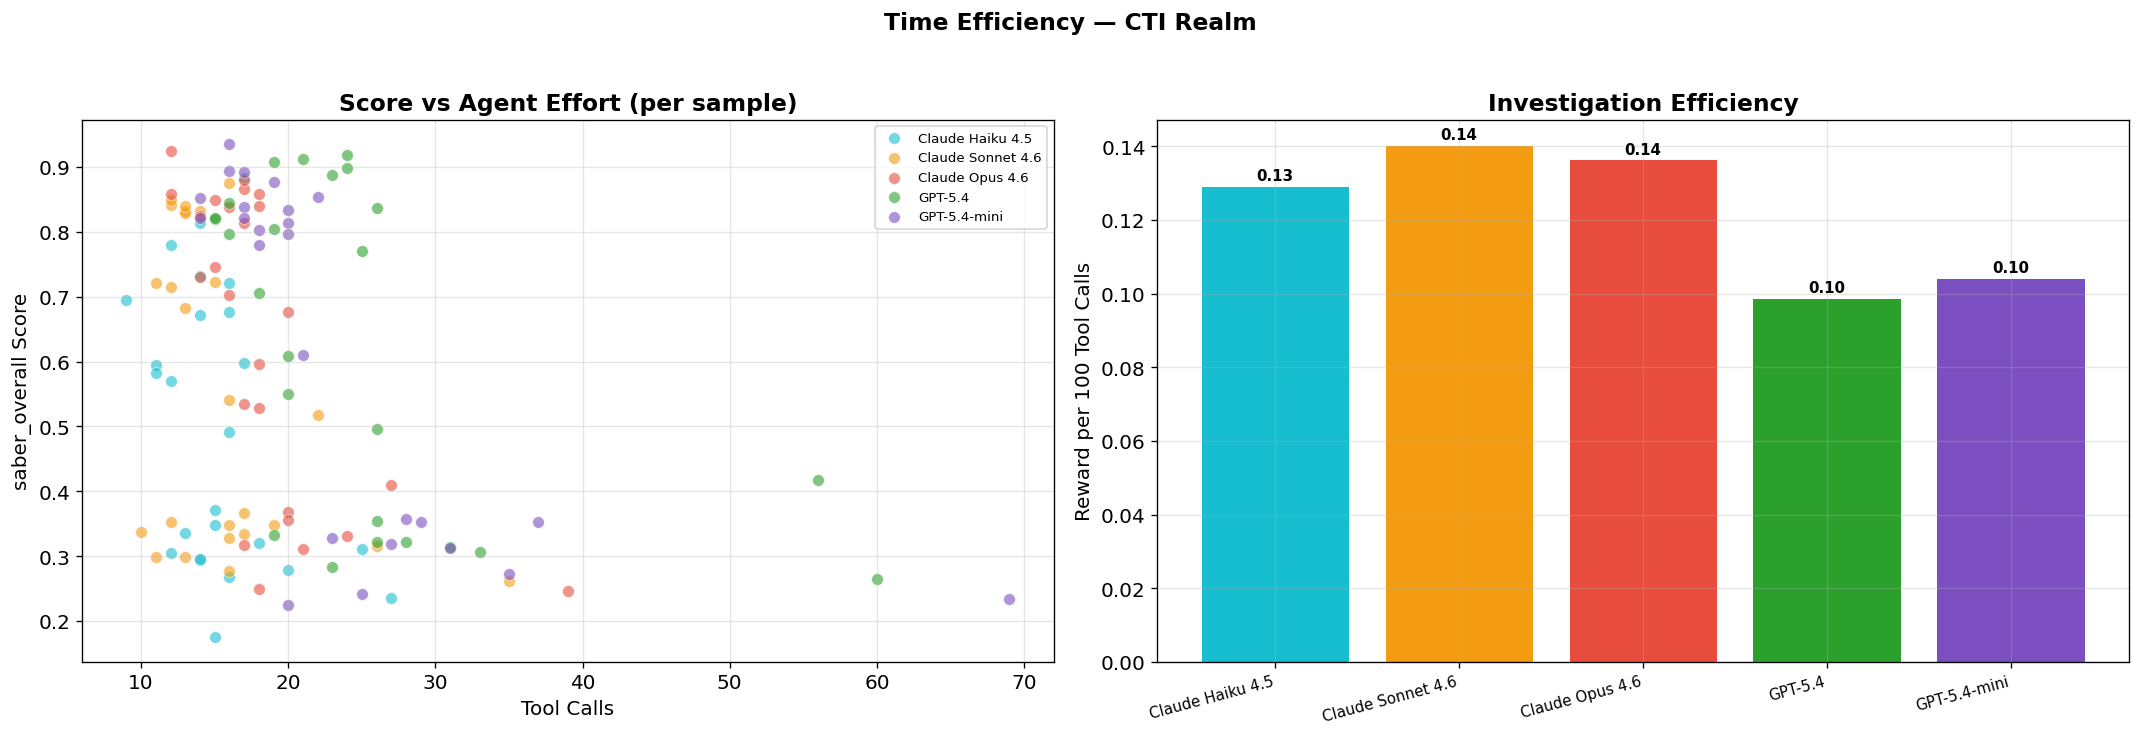

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 11: Time efficiency — reward per tool call
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: scatter plot — tool calls vs reward, per sample
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    axes[0].scatter(mdf['n_tool_calls'], mdf['score'], label=m, color=COLORS[m],
                    alpha=0.6, s=50, edgecolors='w', linewidths=0.5)
axes[0].set_xlabel('Tool Calls'); axes[0].set_ylabel('saber_overall Score')
axes[0].set_title('Score vs Agent Effort (per sample)', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: reward per tool call (bar chart)
eff = {}
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    total_tc = mdf['n_tool_calls'].sum()
    mean_score = mdf['score'].mean()
    eff[m] = mean_score / total_tc * 100 if total_tc else 0  # reward per 100 tool calls

bars = axes[1].bar(range(len(MODEL_ORDER)), [eff[m] for m in MODEL_ORDER],
                   color=[COLORS[m] for m in MODEL_ORDER])
for bar, m in zip(bars, MODEL_ORDER):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{eff[m]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(MODEL_ORDER)))
axes[1].set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
axes[1].set_ylabel('Reward per 100 Tool Calls'); axes[1].set_title('Investigation Efficiency', fontweight='bold')

fig.suptitle(f'Time Efficiency — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'time_efficiency.png', bbox_inches='tight')
plt.show()

### 12. Score Outcome Segmentation by Effort

### What this measures

Segments samples into **effort quartiles** by tool-call count and shows how that correlates with final score.

This reveals whether:
- High-effort tasks are the ones the model struggles with (many tool calls → partial/zero)
- Quick tasks are easy wins (few tool calls → high score)
- More tool calls actually convert to better outcomes

### Key insights (CTI Realm)

- Helps answer: *Do models that use more tools actually perform better?* At the population level, higher effort quartiles don't strongly predict higher scores — suggesting that tasks needing many calls are harder, not that effort helps.
- The per-model panel reveals whether individual models show a positive effort–reward relationship (more calls → better score) or a negative one (diminishing returns from excessive tool use).

/tmp/ipykernel_57384/3669771387.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(bp_data, labels=[str(q) for q in quartiles], patch_artist=True)


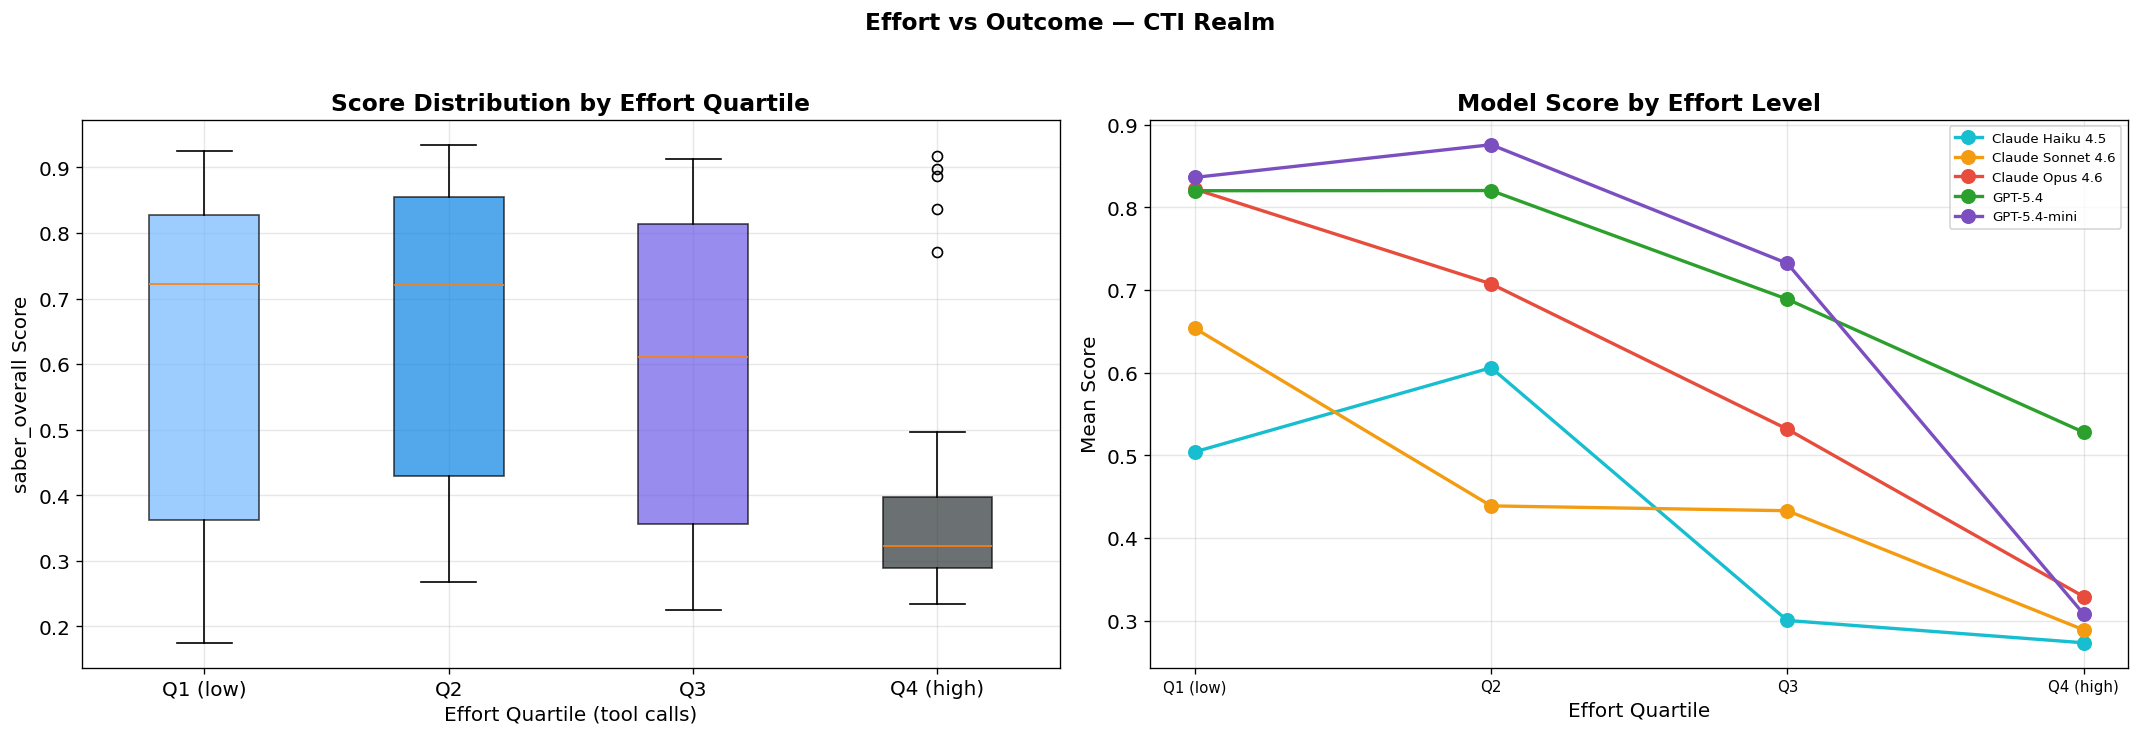

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 12: Score Outcome Segmentation by Effort
# ══════════════════════════════════════════════════════════════════════════════
if len(traj_df) < 8:
    print("⚠️  Not enough samples for effort segmentation — need ≥ 8 data points across models.")
else:
    # Bin samples into effort quartiles (across all models)
    traj_df['effort_q'] = pd.qcut(traj_df['n_tool_calls'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'],
                                   duplicates='drop')

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Left: boxplot of scores per effort quartile
    quartiles = sorted(traj_df['effort_q'].unique())
    bp_data = [traj_df[traj_df['effort_q'] == q]['score'].values for q in quartiles]
    bp = axes[0].boxplot(bp_data, labels=[str(q) for q in quartiles], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#74b9ff', '#0984e3', '#6c5ce7', '#2d3436']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[0].set_xlabel('Effort Quartile (tool calls)')
    axes[0].set_ylabel('saber_overall Score')
    axes[0].set_title('Score Distribution by Effort Quartile', fontweight='bold')

    # Right: per-model mean score by effort quartile
    for m in MODEL_ORDER:
        mdf = traj_df[traj_df['model'] == m]
        means = mdf.groupby('effort_q', observed=True)['score'].mean()
        axes[1].plot(range(len(means)), means.values, 'o-', label=m, color=COLORS[m], linewidth=2, markersize=8)
    axes[1].set_xticks(range(len(quartiles)))
    axes[1].set_xticklabels([str(q) for q in quartiles], fontsize=9)
    axes[1].set_xlabel('Effort Quartile'); axes[1].set_ylabel('Mean Score')
    axes[1].set_title('Model Score by Effort Level', fontweight='bold')
    axes[1].legend(fontsize=8)

    fig.suptitle(f'Effort vs Outcome — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'effort_segmentation.png', bbox_inches='tight')
    plt.show()
    traj_df.drop(columns=['effort_q'], inplace=True, errors='ignore')

### 13. Cross-Model Difficulty Agreement

### What this measures

Do models agree on which tasks are hard? For each pair of models, computes the **Spearman rank correlation** of their per-sample scores.

- **High correlation (> 0.7)** = models agree on task difficulty — some tasks are inherently harder
- **Low correlation (< 0.3)** = models struggle on different tasks — strengths are complementary
- Useful for **ensemble strategies**: low correlation = models complement each other

### Key insights (CTI Realm)

- Cross-model agreement is **generally strong** in CTI Realm (ρ = 0.46–0.84), substantially higher than Excytin's moderate correlations (0.41–0.64). Task difficulty is more intrinsic in this domain — harder tasks are hard for everyone.
- The **strongest agreement** is between GPT-5.4 and GPT-5.4-mini (ρ = 0.835) — same-family models behave very similarly on CTI tasks, unlike Excytin where same-family GPT agreement was surprisingly low (0.41).
- **Claude Opus 4.6 and GPT-5.4-mini** also show strong agreement (ρ = 0.786), suggesting similar task-solving strategies despite different model families.
- The **weakest agreement** is between Claude Haiku 4.5 and Claude Sonnet 4.6 (ρ = 0.464) — within the Claude family, the smaller model takes noticeably different approaches on CTI tasks.
- High cross-model agreement (most pairs > 0.6) means **ensembling across models would provide less benefit** than in Excytin — the complementary strengths are smaller, and a better model simply dominates.
- Notable pairings:
  - GPT-5.4 ↔ GPT-5.4-mini: ρ=0.835 (very strong)
  - Opus ↔ GPT-5.4-mini: ρ=0.786 (strong)
  - Opus ↔ GPT-5.4: ρ=0.721 (strong)
  - Haiku ↔ GPT-5.4-mini: ρ=0.776 (strong)
  - Haiku ↔ Sonnet: ρ=0.464 (weakest — most complementary pair)

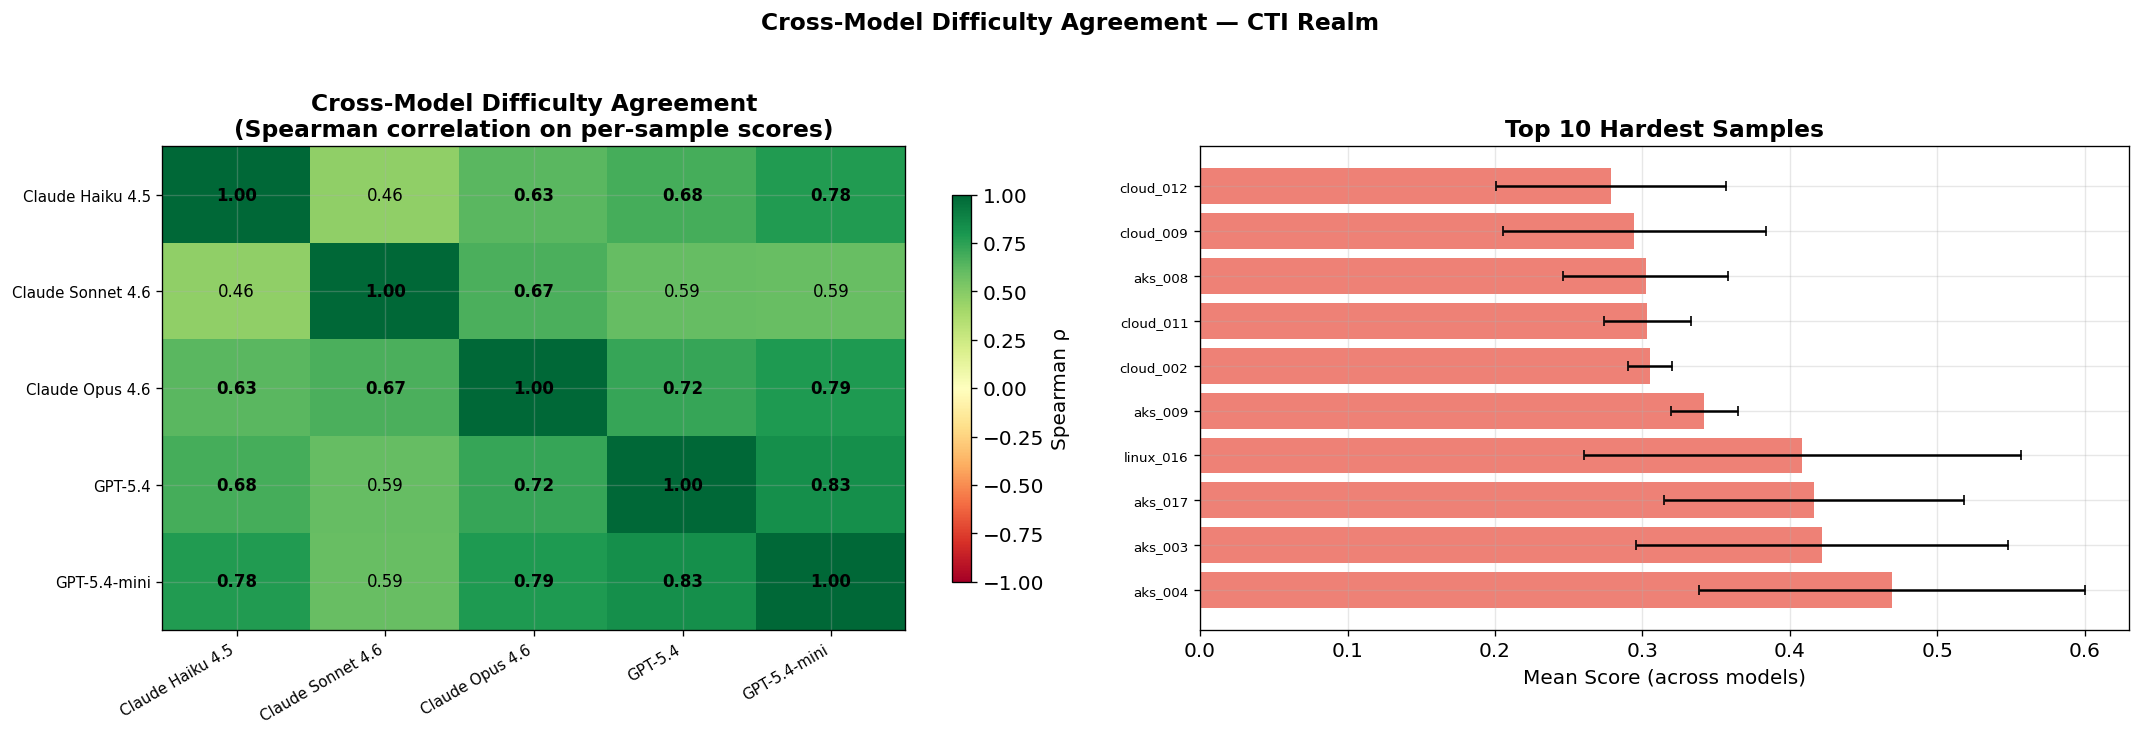


🔴 Hardest samples (lowest mean score):
  cloud_012: mean=0.279, std=0.078
  cloud_009: mean=0.295, std=0.089
  aks_008: mean=0.302, std=0.056
  cloud_011: mean=0.303, std=0.029
  cloud_002: mean=0.305, std=0.015
  aks_009: mean=0.342, std=0.023
  linux_016: mean=0.408, std=0.148
  aks_017: mean=0.416, std=0.102
  aks_003: mean=0.422, std=0.126
  aks_004: mean=0.469, std=0.131

🟢 Easiest samples (highest mean score):
  linux_027: mean=0.878, std=0.042
  linux_012: mean=0.876, std=0.047
  linux_062: mean=0.851, std=0.071
  linux_046: mean=0.828, std=0.087
  linux_015: mean=0.794, std=0.101


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 13: Cross-model difficulty agreement
# ══════════════════════════════════════════════════════════════════════════════
if len(MODEL_ORDER) < 2:
    print("⚠️  Need ≥ 2 models for cross-model difficulty analysis.")
else:
    # Build a pivot: sample_id × model → score (using samples_df)
    score_pivot = samples_df.pivot(index='sample_id', columns='model', values='score')

    # Correlation matrix
    corr = score_pivot[MODEL_ORDER].corr(method='spearman')

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Left: heatmap
    im = axes[0].imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_xticks(range(len(MODEL_ORDER))); axes[0].set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=9)
    axes[0].set_yticks(range(len(MODEL_ORDER))); axes[0].set_yticklabels(MODEL_ORDER, fontsize=9)
    for i in range(len(MODEL_ORDER)):
        for j in range(len(MODEL_ORDER)):
            axes[0].text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10,
                        fontweight='bold' if abs(corr.values[i,j]) > 0.6 else 'normal')
    plt.colorbar(im, ax=axes[0], shrink=0.8, label='Spearman ρ')
    axes[0].set_title('Cross-Model Difficulty Agreement\n(Spearman correlation on per-sample scores)', fontweight='bold')

    # Right: hardest and easiest samples
    score_pivot['mean_score'] = score_pivot[MODEL_ORDER].mean(axis=1)
    score_pivot['std_score'] = score_pivot[MODEL_ORDER].std(axis=1)
    sorted_by_mean = score_pivot.sort_values('mean_score')

    n_show = min(10, len(sorted_by_mean))
    hardest = sorted_by_mean.head(n_show)
    axes[1].barh(range(n_show), hardest['mean_score'].values, xerr=hardest['std_score'].values,
                 color='#e74c3c', alpha=0.7, capsize=3)
    axes[1].set_yticks(range(n_show))
    axes[1].set_yticklabels(hardest.index, fontsize=8)
    axes[1].set_xlabel('Mean Score (across models)')
    axes[1].set_title(f'Top {n_show} Hardest Samples', fontweight='bold')
    axes[1].invert_yaxis()

    fig.suptitle(f'Cross-Model Difficulty Agreement — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'difficulty_agreement.png', bbox_inches='tight')
    plt.show()

    # Print easiest and hardest
    print("\n🔴 Hardest samples (lowest mean score):")
    for sid, row in hardest.iterrows():
        print(f"  {sid}: mean={row['mean_score']:.3f}, std={row['std_score']:.3f}")
    easiest = sorted_by_mean.tail(5)
    print("\n🟢 Easiest samples (highest mean score):")
    for sid, row in easiest.iloc[::-1].iterrows():
        print(f"  {sid}: mean={row['mean_score']:.3f}, std={row['std_score']:.3f}")

---

## 🔬 Domain-Specific Experiments (CTI Realm)

The following experiments analyse **CTI Realm-specific** agent behaviours — CTI report usage, KQL query quality, and checkpoint interdependencies. These are unique to CTI Realm and leverage the domain's 11-tool ecosystem, 5-checkpoint scoring, and multi-step investigation workflow.

### 14. CTI & MITRE Tool Usage Patterns

### What this measures

Examines how each model leverages the **domain-specific information tools** in a 4-panel analysis:

- **(a) Mean Tool Calls per Sample** — grouped bar chart of all 9 CTI tools
- **(b) Investigation Workflow Funnel** — traces the expected flow: `list_cti_report_tags` → `get_cti_reports_by_tag` → `search_mitre_techniques` → `search_sigma_rules` → `execute_kql_query` → `validate_output_json`
- **(c) KQL Query Count Distribution** — violin plot showing per-sample KQL invocation patterns
- **(d) KQL Queries vs. C4 Detection Quality** — scatter plot correlating KQL effort with detection outcome

### Key insights (CTI Realm)

- **GPT-5.4 is the most prolific KQL user**: 9.7 queries/sample vs. Haiku's 3.1 — a 3× difference. GPT models query the data aggressively but don't proportionally convert this into better C4 scores.
- The **workflow funnel** reveals model strategies: Claude models follow a more balanced funnel (moderate use across all tools), while GPT models spike heavily on `execute_kql_query` — they invest disproportionately in data querying relative to CTI report consultation.
- **Claude Sonnet 4.6** has the most balanced tool profile — it invests proportionally across CTI reports, MITRE mapping, and KQL querying, consistent with its high per-call efficiency.
- The **KQL vs. C4 scatter** shows a weak positive correlation — more queries generally help, but diminishing returns set in quickly. GPT-5.4 samples with 15+ KQL queries don't score meaningfully higher than those with 5–10.

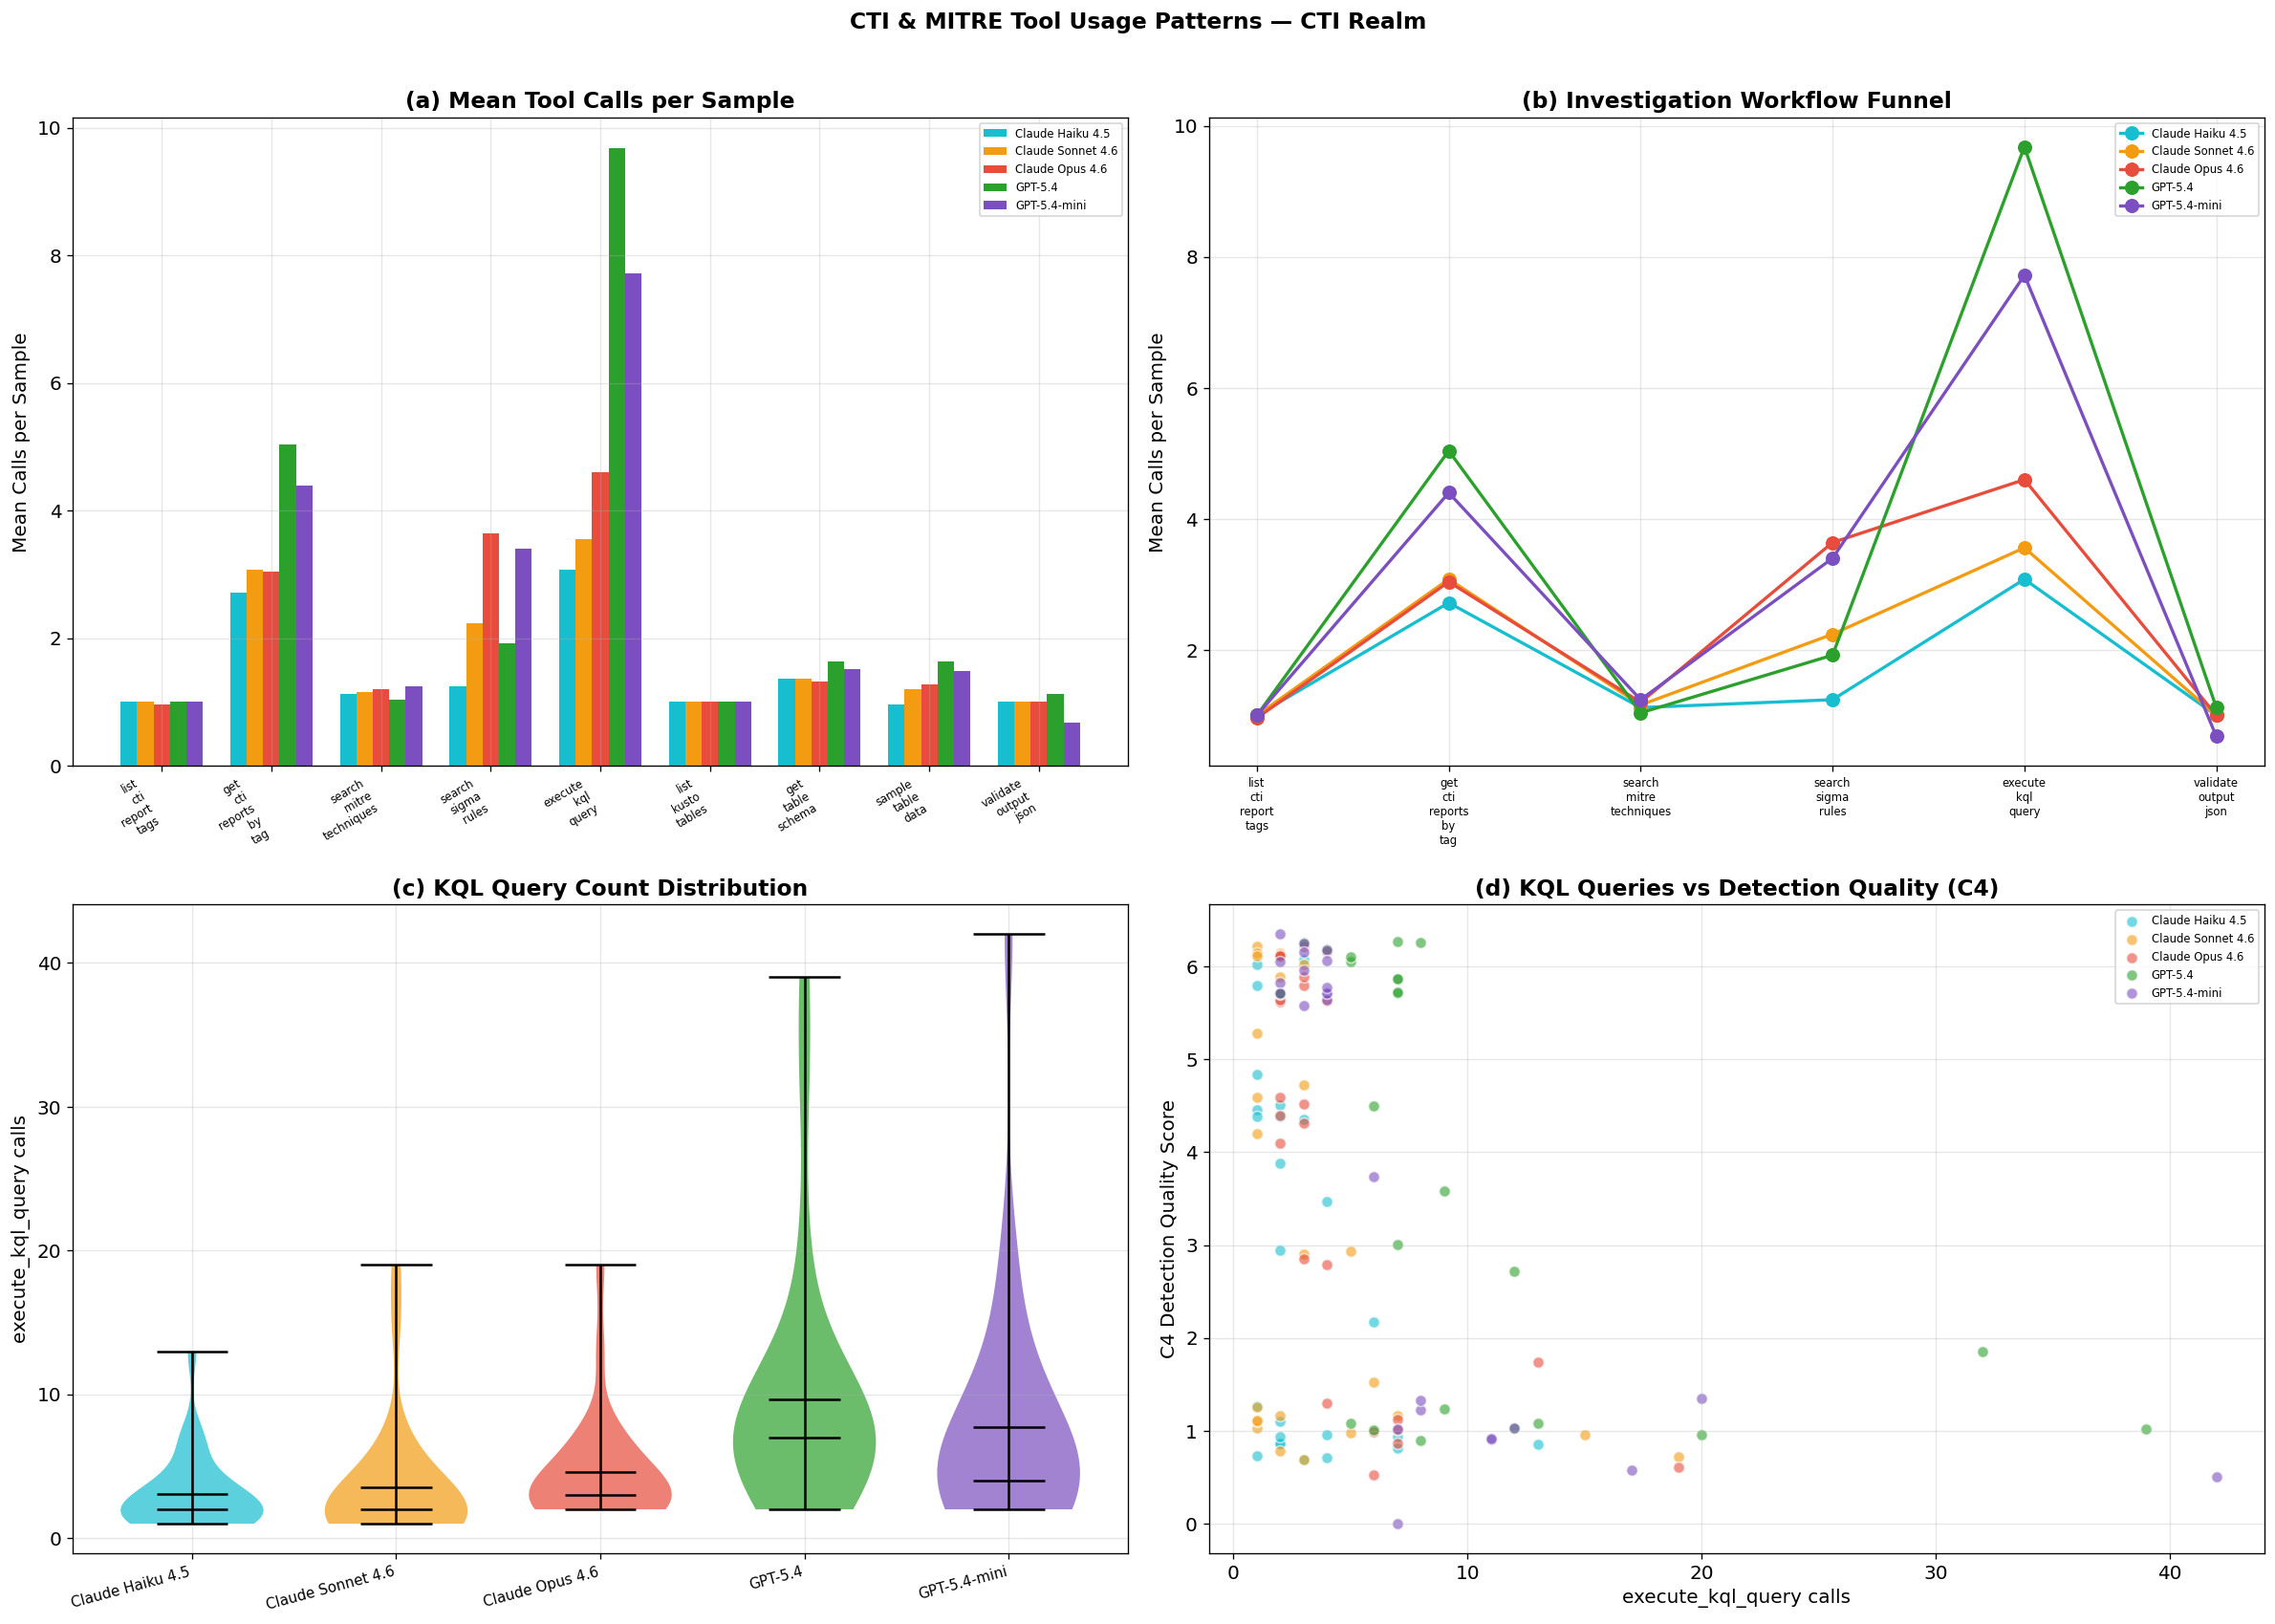

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 14: CTI & MITRE Tool Usage Patterns
# ══════════════════════════════════════════════════════════════════════════════
CTI_TOOLS = [
    'list_cti_report_tags', 'get_cti_reports_by_tag',
    'search_mitre_techniques', 'search_sigma_rules',
    'execute_kql_query', 'list_kusto_tables', 'get_table_schema', 'sample_table_data',
    'validate_output_json',
]

# Build per-sample tool counts from traj_df columns
cti_records = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    for _, row in mdf.iterrows():
        rec = {'model': m, 'sample_id': row['sample_id']}
        for t in CTI_TOOLS:
            col = f'tool_{t}'
            rec[t] = int(row[col]) if col in row.index else 0
        cti_records.append(rec)

cti_df = pd.DataFrame(cti_records)

# Get C4 scores from subtasks_df
c4_lookup = subtasks_df[subtasks_df['score_type'] == 'c4_detection_quality'][['model', 'sample_id', 'score']].copy()
c4_lookup = c4_lookup.rename(columns={'score': 'c4_score'})

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# (a) Top-left: mean calls per tool per model — grouped bar
x = np.arange(len(CTI_TOOLS)); width = 0.15
for i, m in enumerate(MODEL_ORDER):
    mdf = cti_df[cti_df['model'] == m]
    means = [mdf[t].mean() for t in CTI_TOOLS]
    axes[0, 0].bar(x + i * width, means, width, label=m, color=COLORS[m])
axes[0, 0].set_xticks(x + width * (len(MODEL_ORDER) - 1) / 2)
axes[0, 0].set_xticklabels([t.replace('_', '\n') for t in CTI_TOOLS], fontsize=7, rotation=30, ha='right')
axes[0, 0].set_ylabel('Mean Calls per Sample'); axes[0, 0].set_title('(a) Mean Tool Calls per Sample', fontweight='bold')
axes[0, 0].legend(fontsize=7)

# (b) Top-right: workflow funnel
funnel_tools = ['list_cti_report_tags', 'get_cti_reports_by_tag', 'search_mitre_techniques',
                'search_sigma_rules', 'execute_kql_query', 'validate_output_json']
for m in MODEL_ORDER:
    mdf = cti_df[cti_df['model'] == m]
    means = [mdf[t].mean() for t in funnel_tools]
    axes[0, 1].plot(range(len(funnel_tools)), means, 'o-', label=m, color=COLORS[m], linewidth=2, markersize=8)
axes[0, 1].set_xticks(range(len(funnel_tools)))
axes[0, 1].set_xticklabels([t.replace('_', '\n') for t in funnel_tools], fontsize=7)
axes[0, 1].set_ylabel('Mean Calls per Sample')
axes[0, 1].set_title('(b) Investigation Workflow Funnel', fontweight='bold')
axes[0, 1].legend(fontsize=7)

# (c) Bottom-left: KQL query count distribution per model
axes[1, 0].set_title('(c) KQL Query Count Distribution', fontweight='bold')
for i, m in enumerate(MODEL_ORDER):
    data = cti_df[cti_df['model'] == m]['execute_kql_query'].values
    if len(data) > 0:
        vp = axes[1, 0].violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[m]); pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp: vp[part].set_edgecolor('black')
axes[1, 0].set_xticks(range(len(MODEL_ORDER)))
axes[1, 0].set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
axes[1, 0].set_ylabel('execute_kql_query calls')

# (d) Bottom-right: KQL queries vs C4 detection quality
axes[1, 1].set_title('(d) KQL Queries vs Detection Quality (C4)', fontweight='bold')
for m in MODEL_ORDER:
    mdf = cti_df[cti_df['model'] == m].merge(c4_lookup[c4_lookup['model'] == m], on=['model', 'sample_id'], how='left')
    axes[1, 1].scatter(mdf['execute_kql_query'].values, mdf['c4_score'].values, label=m,
                       color=COLORS[m], alpha=0.6, s=50, edgecolors='w')
axes[1, 1].set_xlabel('execute_kql_query calls')
axes[1, 1].set_ylabel('C4 Detection Quality Score')
axes[1, 1].legend(fontsize=7)

fig.suptitle(f'CTI & MITRE Tool Usage Patterns — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cti_tool_patterns.png', bbox_inches='tight')
plt.show()

### 15. KQL Query Quality Analysis

### What this measures

Quantifies KQL query effort per model — how many `execute_kql_query` calls each model makes and how that relates to detection quality (C4). Presented in 3 panels:

- **(a) Total KQL Queries per Model** — absolute count across all 25 samples
- **(b) Per-Sample KQL Query Count** — box plot showing the distribution of queries per task
- **(c) KQL Query Count vs. C4 Detection Quality** — scatter plot testing whether more queries → better detection rules

### Why this matters

KQL query writing is the **core skill** in CTI Realm — agents must write, execute, and iteratively refine Kusto queries to explore data schemas, test hypotheses, and write detection rules. Models that write more targeted, efficient queries will achieve higher C4 scores with fewer attempts.

### Key insights (CTI Realm)

- **Total KQL queries**: GPT-5.4 (242) >> GPT-5.4-mini (193) >> Opus (115) > Sonnet (89) > Haiku (77). GPT models execute **2–3× more queries** than Claude models.
- **Per-sample averages**: GPT-5.4 (9.7/sample) vs. Haiku (3.1/sample). Despite using 3× more queries, GPT-5.4 only achieves 17 percentage points more on C4 (59% vs. 42%).
- The **diminishing returns** pattern is clear: doubling KQL query count does not double C4 score. Claude Opus achieves 58% C4 with only 4.6 queries/sample — making it the most query-efficient model.
- **Box plot reveals GPT variance**: GPT-5.4 has samples ranging from 0 to 25+ queries, while Claude models cluster tightly at 2–6 queries, suggesting GPT takes more variable approaches to tasks.

/tmp/ipykernel_57384/11469854.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=MODEL_ORDER, patch_artist=True)


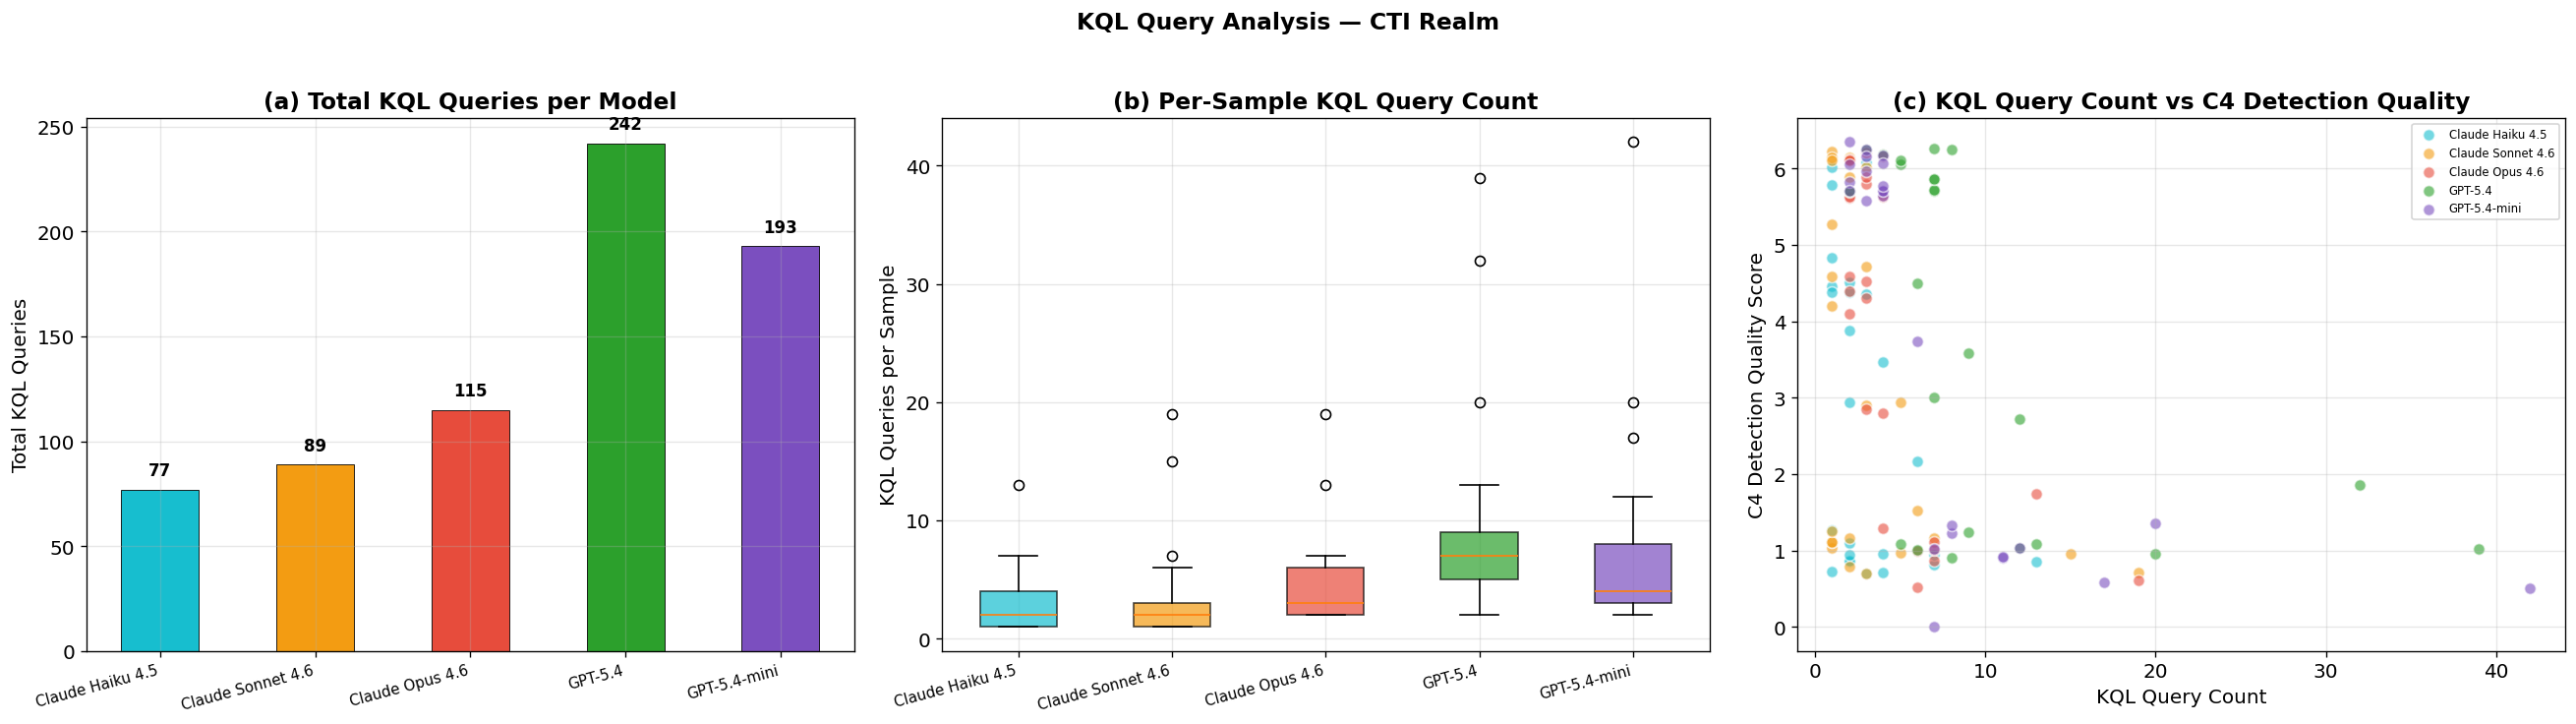


KQL Query Summary:
Model                      Total  Mean/Sample   Median
───────────────────────────────────────────────────────
Claude Haiku 4.5              77          3.1        2
Claude Sonnet 4.6             89          3.6        2
Claude Opus 4.6              115          4.6        3
GPT-5.4                      242          9.7        7
GPT-5.4-mini                 193          7.7        4


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 15: KQL Query Quality Analysis
# ══════════════════════════════════════════════════════════════════════════════
# Build KQL stats from traj_df tool columns (we can count total KQL queries per sample)
# Note: without full tool call results, we approximate success by using C4 score as proxy
kql_records = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    for _, row in mdf.iterrows():
        n_kql = int(row.get('tool_execute_kql_query', 0))
        kql_records.append({
            'model': m, 'sample_id': row['sample_id'],
            'n_kql_total': n_kql,
        })

kql_df = pd.DataFrame(kql_records)

# Get C4 scores
c4_lookup = subtasks_df[subtasks_df['score_type'] == 'c4_detection_quality'][['model', 'sample_id', 'score']].copy()
c4_lookup = c4_lookup.rename(columns={'score': 'c4_score'})
kql_df = kql_df.merge(c4_lookup, on=['model', 'sample_id'], how='left')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) KQL query count per model
x = np.arange(len(MODEL_ORDER)); width = 0.5
totals = [kql_df[kql_df['model'] == m]['n_kql_total'].sum() for m in MODEL_ORDER]
colors_list = [COLORS[m] for m in MODEL_ORDER]
axes[0].bar(x, totals, width, color=colors_list, edgecolor='black', linewidth=0.5)
for i, v in enumerate(totals):
    axes[0].text(i, v + max(totals)*0.02, str(v), ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_xticks(x); axes[0].set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
axes[0].set_ylabel('Total KQL Queries'); axes[0].set_title('(a) Total KQL Queries per Model', fontweight='bold')

# (b) KQL queries per sample (box plot)
bp_data = [kql_df[kql_df['model'] == m]['n_kql_total'].values for m in MODEL_ORDER]
bp = axes[1].boxplot(bp_data, labels=MODEL_ORDER, patch_artist=True)
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(COLORS[m]); patch.set_alpha(0.7)
axes[1].set_ylabel('KQL Queries per Sample'); axes[1].set_title('(b) Per-Sample KQL Query Count', fontweight='bold')
axes[1].set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')

# (c) Scatter: KQL count vs C4 score
axes[2].set_title('(c) KQL Query Count vs C4 Detection Quality', fontweight='bold')
for m in MODEL_ORDER:
    mdf = kql_df[kql_df['model'] == m]
    axes[2].scatter(mdf['n_kql_total'].values, mdf['c4_score'].values, label=m,
                    color=COLORS[m], alpha=0.6, s=50, edgecolors='w')
axes[2].set_xlabel('KQL Query Count')
axes[2].set_ylabel('C4 Detection Quality Score')
axes[2].legend(fontsize=7)

fig.suptitle(f'KQL Query Analysis — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'kql_quality.png', bbox_inches='tight')
plt.show()

# Summary table
print("\nKQL Query Summary:")
print(f"{'Model':<25} {'Total':>6} {'Mean/Sample':>12} {'Median':>8}")
print("─" * 55)
for m in MODEL_ORDER:
    mdf = kql_df[kql_df['model'] == m]
    t = mdf['n_kql_total'].sum()
    avg = mdf['n_kql_total'].mean()
    med = mdf['n_kql_total'].median()
    print(f"{m:<25} {t:>6} {avg:>12.1f} {med:>8.0f}")

### 16. Checkpoint Correlation Analysis

### What this measures

Examines **interdependencies** between the 5 CTI Realm checkpoints using Spearman rank correlation. Key questions:

- **C0 ↔ C1**: Does correct CTI alignment predict MITRE technique identification?
- **C2 ↔ C4**: Does thorough data exploration lead to better detection rules?
- **C0 ↔ C4**: Is overall CTI understanding a prerequisite for detection quality?

### How to read the chart

- **Left panel**: Checkpoint correlation matrix — red = positive correlation, blue = negative
- **Right panel**: Key scatter — C0 (CTI Alignment) vs. C4 (Detection Quality) with trend line
- Correlation values > 0.3 suggest meaningful relationships; < 0.1 = essentially independent

### Key insights (CTI Realm)

- **Checkpoints are remarkably independent** — almost all pairwise correlations are weak (|ρ| < 0.2). The 5 checkpoints measure genuinely distinct capabilities.
- The **strongest correlation** is C2 (Data Exploration) ↔ C4 (Detection Quality) at ρ=0.384 — the only moderate relationship. Models that explore data schemas more thoroughly write better KQL detection rules, as expected.
- **C1 (MITRE) ↔ C4 (Detection)** have a weak positive correlation (ρ=0.270) — identifying the right MITRE techniques provides some signal for detection quality, but models can write good detections without perfectly mapping techniques.
- **C0 (CTI Alignment) does NOT predict C4 (Detection Quality)** (ρ=-0.085) — this is a key finding: reading CTI reports well doesn't translate to writing better detection rules. These are independent skills.
- **C3 (Query Iteration) is independent of everything** (all |ρ| < 0.16) — whether an agent runs ≥2 queries is unrelated to how well it performs on any other dimension.
- The independence of checkpoints validates CTI Realm's scoring design — each checkpoint captures a genuinely distinct aspect of the threat intelligence workflow, and high marks on one don't guarantee competence on another.

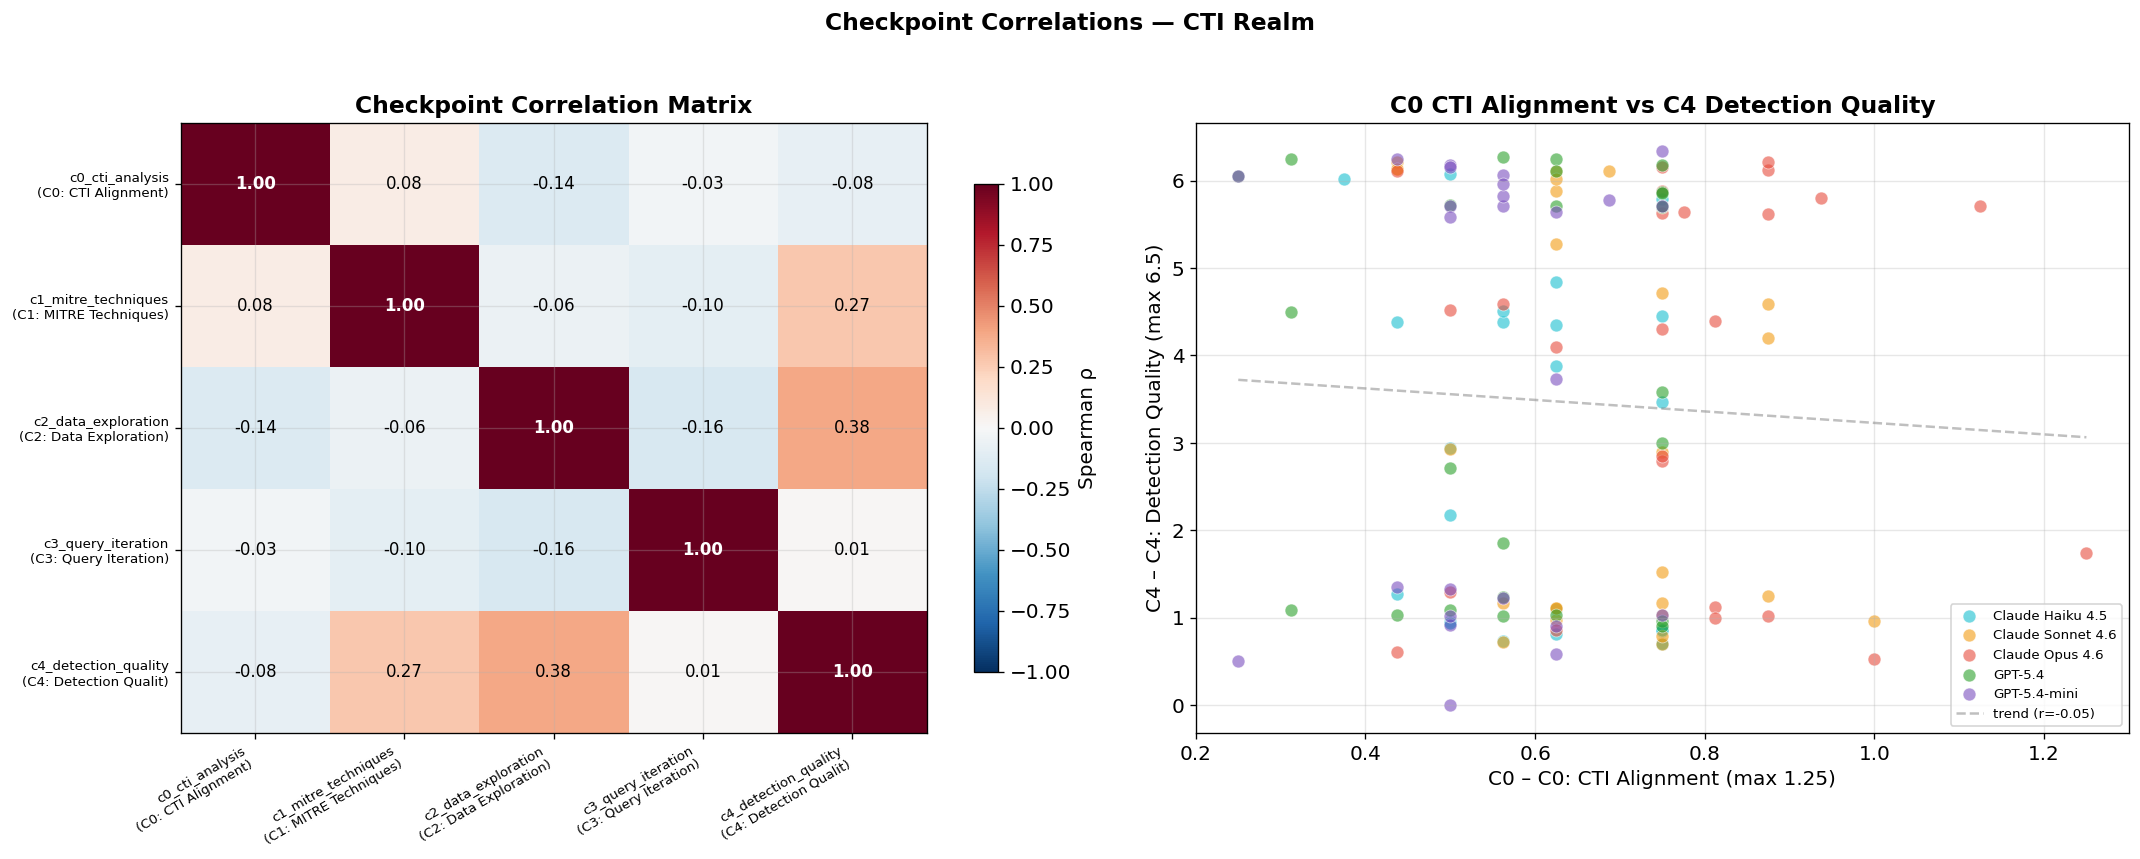


Checkpoint Correlation Summary (Spearman ρ):
  C0: CTI Alignment ↔ C1: MITRE Techniques: ρ=0.076 (⚪ weak)
  C0: CTI Alignment ↔ C2: Data Exploration: ρ=-0.136 (⚪ weak)
  C0: CTI Alignment ↔ C3: Query Iteration: ρ=-0.030 (⚪ weak)
  C0: CTI Alignment ↔ C4: Detection Quality: ρ=-0.085 (⚪ weak)
  C1: MITRE Techniques ↔ C2: Data Exploration: ρ=-0.057 (⚪ weak)
  C1: MITRE Techniques ↔ C3: Query Iteration: ρ=-0.101 (⚪ weak)
  C1: MITRE Techniques ↔ C4: Detection Quality: ρ=0.270 (⚪ weak)
  C2: Data Exploration ↔ C3: Query Iteration: ρ=-0.158 (⚪ weak)
  C2: Data Exploration ↔ C4: Detection Quality: ρ=0.384 (🟡 moderate)
  C3: Query Iteration ↔ C4: Detection Quality: ρ=0.014 (⚪ weak)


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 16: Checkpoint Correlation Analysis
# ══════════════════════════════════════════════════════════════════════════════
checkpoints = list(CHECKPOINT_NAMES.keys())

# Build checkpoint score dataframe from subtasks_df
ckpt_records = []
for m in MODEL_ORDER:
    m_sub = subtasks_df[subtasks_df['model'] == m]
    for sid in m_sub['sample_id'].unique():
        row = {'model': m, 'sample_id': sid}
        sid_sub = m_sub[m_sub['sample_id'] == sid]
        for ck in checkpoints:
            ck_scores = sid_sub[sid_sub['score_type'] == ck]['score']
            row[ck] = ck_scores.values[0] if len(ck_scores) > 0 else np.nan
        ckpt_records.append(row)
ckpt_df = pd.DataFrame(ckpt_records)

# Spearman correlation matrix across checkpoints
ckpt_corr = ckpt_df[checkpoints].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: correlation heatmap
labels = [f'{ck}\n({CHECKPOINT_NAMES[ck][:20]})' for ck in checkpoints]
im = axes[0].imshow(ckpt_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(checkpoints))); axes[0].set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
axes[0].set_yticks(range(len(checkpoints))); axes[0].set_yticklabels(labels, fontsize=8)
for i in range(len(checkpoints)):
    for j in range(len(checkpoints)):
        axes[0].text(j, i, f'{ckpt_corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10,
                    fontweight='bold' if abs(ckpt_corr.values[i,j]) > 0.5 else 'normal',
                    color='white' if abs(ckpt_corr.values[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=axes[0], shrink=0.8, label='Spearman ρ')
axes[0].set_title('Checkpoint Correlation Matrix', fontweight='bold')

# Right: key scatter — C0 (CTI Alignment) vs C4 (Detection Quality)
c0_key = 'c0_cti_analysis'
c4_key = 'c4_detection_quality'
axes[1].set_title('C0 CTI Alignment vs C4 Detection Quality', fontweight='bold')
for m in MODEL_ORDER:
    mdf = ckpt_df[ckpt_df['model'] == m]
    axes[1].scatter(mdf[c0_key].values, mdf[c4_key].values, label=m,
                    color=COLORS[m], alpha=0.6, s=60, edgecolors='w', linewidths=0.5)
# Trend line
valid = ckpt_df[[c0_key, c4_key]].dropna()
if len(valid) > 2:
    z = np.polyfit(valid[c0_key], valid[c4_key], 1)
    p = np.poly1d(z)
    x_range = np.linspace(valid[c0_key].min(), valid[c0_key].max(), 100)
    axes[1].plot(x_range, p(x_range), '--', color='gray', alpha=0.5, linewidth=1.5,
                 label=f'trend (r={valid[c0_key].corr(valid[c4_key]):.2f})')
axes[1].set_xlabel(f'C0 – {CHECKPOINT_NAMES[c0_key]} (max {CHECKPOINT_MAX_SCORES[c0_key]})')
axes[1].set_ylabel(f'C4 – {CHECKPOINT_NAMES[c4_key]} (max {CHECKPOINT_MAX_SCORES[c4_key]})')
axes[1].legend(fontsize=8)

fig.suptitle(f'Checkpoint Correlations — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_correlations.png', bbox_inches='tight')
plt.show()

# Print notable correlations
print("\nCheckpoint Correlation Summary (Spearman ρ):")
for i, ck1 in enumerate(checkpoints):
    for j, ck2 in enumerate(checkpoints):
        if j > i:
            rho = ckpt_corr.loc[ck1, ck2]
            strength = "🔴 strong" if abs(rho) > 0.6 else "🟡 moderate" if abs(rho) > 0.3 else "⚪ weak"
            print(f"  {CHECKPOINT_NAMES[ck1]} ↔ {CHECKPOINT_NAMES[ck2]}: ρ={rho:.3f} ({strength})")

---

## Key Takeaways

### Performance

- CTI Realm is **significantly harder** than Excytin: top score is 0.626 (Opus) vs. 0.875 (GPT-5.4 on Excytin). No model achieves even 65% of the maximum score.
- **Claude Opus 4.6** leads (0.626), followed closely by **GPT-5.4** (0.620) and **GPT-5.4-mini** (0.617). Claude Haiku 4.5 trails at 0.494.
- **Extended reasoning shows a dramatic family split**: GPT models gain +0.16–0.18 from reasoning (the largest observed in any SABER domain), while Claude models show no benefit or slight regression. This suggests CTI Realm's multi-step workflow particularly rewards explicit chain-of-thought.
- **Platform difficulty hierarchy is stark**: Linux (avg=0.717) >> AKS (avg=0.429) >> Cloud (avg=0.295). Cloud tasks are extremely challenging for all models.

### Efficiency

- **Claude Sonnet 4.6 has the best reward/call** (0.0350): highest score gain per tool invocation, despite being a mid-tier scorer. It works entirely through domain-specific tools (zero bash/python calls).
- **GPT models have a severe latency problem**: 10+ minutes per sample vs. 2–3 minutes for Claude models. GPT-5.4 costs $123.61 for only marginally higher scores than Opus ($50.85), yielding the worst cost efficiency (0.005 score/$).
- **Claude Haiku 4.5** is the most cost-efficient model at 0.204 score/$ — **41× better** than GPT-5.4 — making it ideal for budget-constrained deployments despite lower absolute scores.

### Behavioral Patterns

- Models use **15–25 tool calls** on average, with the 70-call budget being sufficient. Claude models plateau by 20–24 calls; GPT models need 33–35 calls for 95% of their score.
- **KQL / Data exploration dominates** tool usage (~48% of all calls), followed by CTI / MITRE (~29%). GPT-5.4 executes 3× more KQL queries than Claude Haiku, but the extra effort shows diminishing returns.
- Cross-model agreement on task difficulty is **strong** (ρ=0.46–0.84), substantially higher than Excytin. Harder CTI tasks are consistently hard across all models.

### Checkpoint Analysis (Domain-Specific)

- **C4 (Detection Quality)** is the universal bottleneck — no model exceeds 59% of the max 6.5 points. Since C4 is 65% of total score, improving KQL/Sigma quality is the highest-leverage intervention.
- **C3 (Query Iteration)** is nearly fully solved — GPT-5.4-mini achieves 100%, and most models hit 92%+.
- **Checkpoints are genuinely independent** (all pairwise |ρ| < 0.4): reading CTI reports well (C0) does NOT predict better detection rules (C4), and broad data exploration (C2) is only weakly correlated with detection quality (ρ=0.38).
- **Claude Opus** is the best at CTI grounding (C0=61%); **GPT models** are the best at detection writing (C4=59%) and MITRE mapping (C1=85%); **Haiku** paradoxically leads in data exploration (C2=77%) despite the lowest overall score.

---

## Next Steps

### Adding your own models

1. Run: `uv run inspect eval domains/cti_realm --model <model_id> --display plain`
2. Copy the `.eval` file to `eval_samples/cti_realm/`
3. Edit the **Configuration cell** above
4. Re-run the notebook

### Potential follow-up analyses
1. **Per-platform deep dive** — Run separate analysis for Linux vs AKS vs Cloud samples to identify platform-specific model strengths
2. **Error analysis** — Extract and classify agent failures (timeout, wrong tool, hallucinated KQL)
3. **Reasoning ablation** — Compare reasoning vs no-reasoning runs (Experiments use `NO_THINKING_LOGS`)
4. **Scale to 50+ samples** — Expand dataset for statistical power on per-platform comparisons
5. **Agent strategy comparison** — Compare different agent architectures on the same tasks

### Data loading notes

All log parsing uses **inspect_ai's typed log API**:
- `read_eval_log(header_only=True)` for run-level results, config, and limits
- `read_eval_log_sample_summaries()` for per-sample scores, timing, and model usage
- `read_eval_log_sample(id=...)` for full message/tool-call detail per sample

### Further reading

- **[README.md](../README.md)** — Installation, domains, agents, CLI
- `uv run inspect view` — Interactive log viewer

### Artifacts saved to `artifacts/cti_realm/`:
- `overall_reward.png` — Experiment 1
- `per_platform_scores.png` — Experiment 2
- `cost_analysis.png` — Experiment 3
- `token_usage.png` — Experiment 4
- `cost_efficiency.png` — Experiment 5
- `checkpoint_breakdown.png` — Experiment 6
- `checkpoint_distributions.png` — Experiment 7
- `checkpoint_heatmap.png` — Experiment 8
- `score_vs_tool_call_limit.png`, `effort_distributions.png` — Experiment 9
- `tool_usage.png` — Experiment 10
- `time_efficiency.png` — Experiment 11
- `effort_segmentation.png` — Experiment 12
- `difficulty_agreement.png` — Experiment 13
- `cti_tool_patterns.png` — Experiment 14
- `kql_quality.png` — Experiment 15
- `checkpoint_correlations.png` — Experiment 16